In [1]:
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/code")

from parse_gtf import *
from junction2psi import *

pd.set_option('display.max_columns', None)

## First cluster MEs

In [2]:
ctype_abundance_df = pd.read_csv("data/ctype_abundance/GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance.csv", index_col=0)

In [3]:
ctype_abundance_df.head()

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Sample,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GTEX.1117F.0011.R10b.SM.GI4VE,-0.057866,-0.036594,-0.037142,-0.025971,-0.019137,-0.015805,-0.016215,-0.023874,-0.038468,-0.057866,-0.044356,-0.037028,-0.057866,-0.057866,-0.060943,-0.043617,0.007780,-0.039248,-0.059617,-0.051635,0.003781,-0.047065,-0.060943,-0.051635,-0.051635,-0.082838,-0.030317,-0.038468,-0.033833,-0.047530
GTEX.1117F.3226.SM.5N9CT,-0.053903,-0.021822,-0.031820,0.046679,-0.029398,-0.007065,-0.015931,-0.022546,-0.015077,-0.053903,-0.041789,-0.012392,-0.053903,-0.053903,-0.057669,-0.014388,-0.029253,-0.039266,-0.054340,-0.051459,0.001205,-0.067544,-0.057669,-0.051459,-0.051459,-0.032636,-0.031800,-0.015077,-0.035939,-0.043929
GTEX.111FC.0011.R10a.SM.GIN8G,0.100782,0.000821,0.145417,0.001138,0.034416,-0.000086,-0.010771,-0.024556,0.145353,0.100782,0.075111,-0.001230,0.100782,0.100782,0.047161,0.136909,0.155514,0.100888,0.095841,0.084702,0.174663,0.050053,0.047161,0.084702,0.084702,0.026497,0.067358,0.145353,0.151758,0.024058
GTEX.111FC.0011.R3b.SM.GJ3PN,0.070749,-0.015060,0.076446,-0.027452,0.012491,-0.037843,-0.014814,-0.027781,0.060452,0.070749,-0.014245,-0.034165,0.070749,0.070749,0.059273,0.067754,0.116728,0.129726,0.069907,0.099127,0.094326,0.023006,0.059273,0.099127,0.099127,0.006656,0.186288,0.060452,0.064768,0.015286
GTEX.1128S.2726.SM.5H12C,-0.006793,-0.032135,-0.004225,-0.008868,-0.013577,-0.010716,-0.007305,-0.011536,0.007139,-0.006793,0.022459,0.005337,-0.006793,-0.006793,0.000158,-0.003523,-0.013362,-0.026190,-0.007885,-0.013966,-0.010611,0.014895,0.000158,-0.013966,-0.013966,0.000221,-0.028048,0.007139,-0.003194,-0.012145


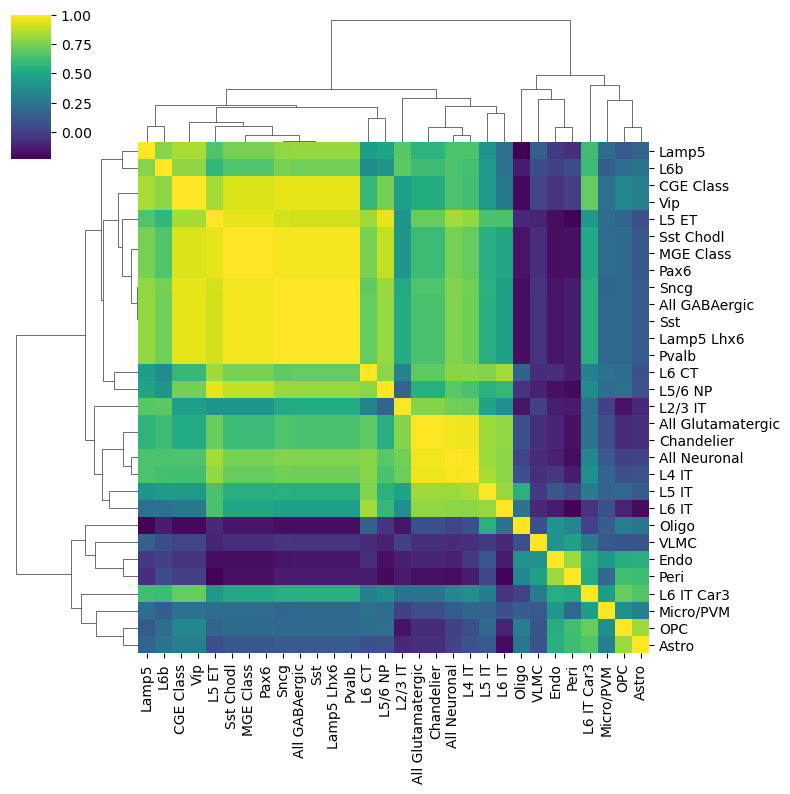

In [4]:
abund_corr_mat = ctype_abundance_df.corr()
sns.clustermap(abund_corr_mat, cmap='viridis', figsize=(8, 8))

## Cluster by gene expression corr

In [5]:
expr_corr_df = pd.read_csv("data/corrs/GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance_gene_expr_corr.csv", index_col=0)

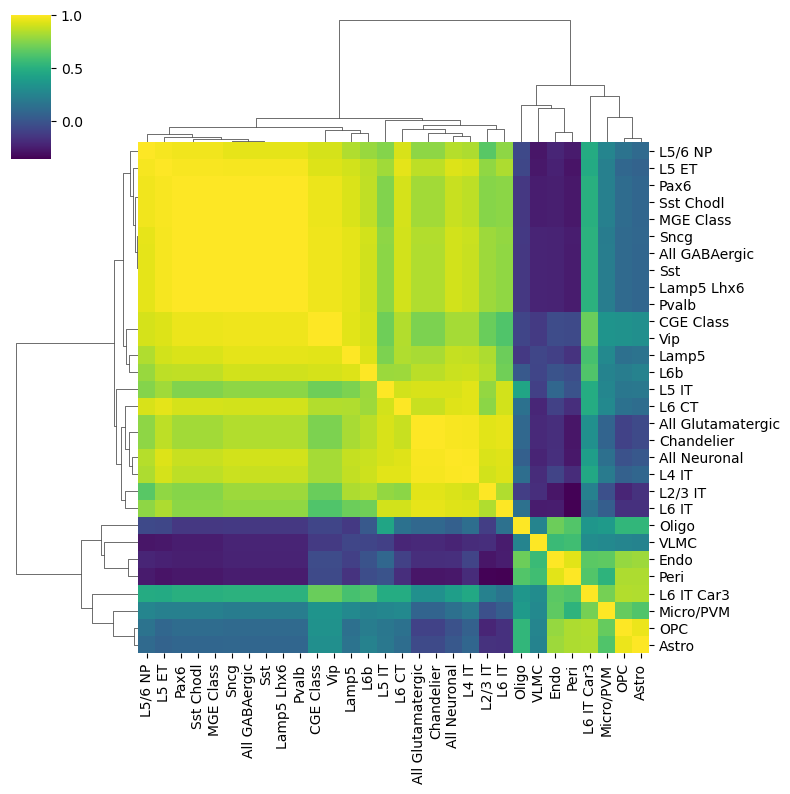

In [6]:
expr_corr_mat = expr_corr_df.corr()
sns.clustermap(expr_corr_mat, cmap='viridis', figsize=(8, 8))

### Manually inspect top genes

In [7]:
keep = []

In [8]:
expr_corr_df.sort_values("L5/6 NP", ascending=False).head(15)

# Looks more inhibitory / poorly defined.

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SPHKAP,0.774463,0.110006,0.672556,-0.132424,0.094158,-0.234961,-0.132925,-0.003601,0.542934,0.774463,0.189357,-0.247966,0.774463,0.774463,0.696283,0.507277,0.732292,0.912936,0.781931,0.848126,0.575151,0.484951,0.696283,0.848126,0.848126,0.374786,0.941351,0.542934,0.638111,0.306401
HTR7,0.732836,0.103154,0.564960,-0.124818,0.151070,-0.206498,-0.098273,0.013092,0.434537,0.732836,0.108207,-0.226511,0.732836,0.732836,0.677084,0.423931,0.603534,0.860826,0.741442,0.808913,0.430557,0.480387,0.677084,0.808913,0.808913,0.367738,0.912634,0.434537,0.523801,0.326739
VAT1L,0.633691,0.220642,0.581034,-0.032738,0.175993,-0.144877,-0.111673,0.104961,0.455327,0.633691,0.052267,-0.166919,0.633691,0.633691,0.582136,0.477220,0.689453,0.830357,0.643076,0.725679,0.536504,0.341774,0.582136,0.725679,0.725679,0.265788,0.905099,0.455327,0.555506,0.289801
RAB3B,0.752782,0.089825,0.582102,-0.035569,0.157656,-0.245355,-0.125707,-0.068378,0.466279,0.752782,0.151828,-0.257478,0.752782,0.752782,0.644120,0.514163,0.743272,0.847968,0.750865,0.824144,0.563134,0.380215,0.644120,0.824144,0.824144,0.351905,0.885294,0.466279,0.533044,0.229801
CRHBP,0.832750,0.114353,0.527940,-0.140119,0.165389,-0.260813,-0.137805,-0.011568,0.383425,0.832750,0.170099,-0.255295,0.832750,0.832750,0.742517,0.394911,0.642051,0.862069,0.832652,0.895097,0.405001,0.513423,0.742517,0.895097,0.895097,0.397266,0.873314,0.383425,0.483176,0.294377
LHX6,0.905680,0.130554,0.695686,-0.115804,0.131723,-0.222249,-0.125122,0.025178,0.583182,0.905680,0.327948,-0.205908,0.905680,0.905680,0.809709,0.540027,0.724431,0.910428,0.907278,0.933311,0.538782,0.540822,0.809709,0.933311,0.933311,0.524012,0.869244,0.583182,0.648644,0.354907
PID1,0.794107,0.465000,0.718779,-0.030317,0.273934,-0.003978,-0.077116,0.360646,0.586238,0.794107,0.305389,0.021756,0.794107,0.794107,0.790951,0.588442,0.770371,0.876651,0.793049,0.824856,0.513231,0.559926,0.790951,0.824856,0.824856,0.543285,0.861796,0.586238,0.701530,0.584097
SLC17A8,0.698230,0.300789,0.418647,-0.061543,0.183092,-0.164903,-0.115159,0.129475,0.268300,0.698230,-0.006233,-0.140397,0.698230,0.698230,0.665573,0.361443,0.660808,0.778003,0.697890,0.784123,0.368031,0.396367,0.665573,0.784123,0.784123,0.281370,0.860425,0.268300,0.386707,0.346149
BCL11B,0.763113,0.243182,0.638136,-0.086612,0.097150,-0.214404,-0.158788,0.155673,0.508255,0.763113,0.235529,-0.189139,0.763113,0.763113,0.751080,0.486744,0.681286,0.853957,0.776449,0.821793,0.456912,0.552953,0.751080,0.821793,0.821793,0.460453,0.853388,0.508255,0.617244,0.392200


In [9]:
expr_corr_df.sort_values("L5 ET", ascending=False).head(15)

# Looks more generally inhibitory, general neuronal

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SPHKAP,0.774463,0.110006,0.672556,-0.132424,0.094158,-0.234961,-0.132925,-0.003601,0.542934,0.774463,0.189357,-0.247966,0.774463,0.774463,0.696283,0.507277,0.732292,0.912936,0.781931,0.848126,0.575151,0.484951,0.696283,0.848126,0.848126,0.374786,0.941351,0.542934,0.638111,0.306401
LHX6,0.905680,0.130554,0.695686,-0.115804,0.131723,-0.222249,-0.125122,0.025178,0.583182,0.905680,0.327948,-0.205908,0.905680,0.905680,0.809709,0.540027,0.724431,0.910428,0.907278,0.933311,0.538782,0.540822,0.809709,0.933311,0.933311,0.524012,0.869244,0.583182,0.648644,0.354907
GAD1,0.950111,0.044950,0.725454,-0.240216,0.172472,-0.250282,-0.141270,-0.023831,0.605246,0.950111,0.451149,-0.271098,0.950111,0.950111,0.850453,0.484353,0.691754,0.905739,0.948402,0.957639,0.489757,0.720348,0.850453,0.957639,0.957639,0.592770,0.809642,0.605246,0.692475,0.385204
MAP2,0.832018,0.110690,0.783906,-0.134530,0.230660,-0.194716,-0.136960,0.051260,0.665639,0.832018,0.468870,-0.241353,0.832018,0.832018,0.756037,0.578487,0.767584,0.887796,0.823828,0.848070,0.568653,0.621135,0.756037,0.848070,0.848070,0.542531,0.815299,0.665639,0.749427,0.393827
GAD2,0.948961,0.031563,0.701861,-0.254368,0.134219,-0.271038,-0.135228,-0.027668,0.578225,0.948961,0.455679,-0.270954,0.948961,0.948961,0.848021,0.461600,0.675024,0.886851,0.945134,0.950350,0.469757,0.724925,0.848021,0.950350,0.950350,0.581975,0.787153,0.578225,0.665133,0.372375
SMIM17,0.838406,0.067103,0.753575,-0.154641,0.155874,-0.237518,-0.164893,0.007080,0.636233,0.838406,0.391093,-0.296667,0.838406,0.838406,0.754491,0.542645,0.785817,0.882400,0.839835,0.870253,0.599060,0.664343,0.754491,0.870253,0.870253,0.501309,0.805090,0.636233,0.743557,0.348717
PID1,0.794107,0.465000,0.718779,-0.030317,0.273934,-0.003978,-0.077116,0.360646,0.586238,0.794107,0.305389,0.021756,0.794107,0.794107,0.790951,0.588442,0.770371,0.876651,0.793049,0.824856,0.513231,0.559926,0.790951,0.824856,0.824856,0.543285,0.861796,0.586238,0.701530,0.584097
FSTL5,0.863993,0.121741,0.730375,-0.176266,0.146538,-0.203095,-0.135223,0.096381,0.600157,0.863993,0.407885,-0.238211,0.863993,0.863993,0.806717,0.525859,0.774658,0.874416,0.862158,0.883954,0.553641,0.731115,0.806717,0.883954,0.883954,0.556366,0.796789,0.600157,0.718482,0.419665
MYO5B,0.894943,-0.034665,0.757463,-0.174545,0.148443,-0.229255,-0.059388,-0.102780,0.660841,0.894943,0.470093,-0.263725,0.894943,0.894943,0.747526,0.548961,0.716961,0.873534,0.889378,0.896524,0.585060,0.634229,0.747526,0.896524,0.896524,0.504538,0.764804,0.660841,0.723628,0.291132


In [10]:
expr_corr_df.sort_values("Pax6", ascending=False).head(20)

# Not meaningfully distinguishable from GABAergic...

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GAD1,0.950111,0.044950,0.725454,-0.240216,0.172472,-0.250282,-0.141270,-0.023831,0.605246,0.950111,0.451149,-0.271098,0.950111,0.950111,0.850453,0.484353,0.691754,0.905739,0.948402,0.957639,0.489757,0.720348,0.850453,0.957639,0.957639,0.592770,0.809642,0.605246,0.692475,0.385204
GAD2,0.948961,0.031563,0.701861,-0.254368,0.134219,-0.271038,-0.135228,-0.027668,0.578225,0.948961,0.455679,-0.270954,0.948961,0.948961,0.848021,0.461600,0.675024,0.886851,0.945134,0.950350,0.469757,0.724925,0.848021,0.950350,0.950350,0.581975,0.787153,0.578225,0.665133,0.372375
LHX6,0.905680,0.130554,0.695686,-0.115804,0.131723,-0.222249,-0.125122,0.025178,0.583182,0.905680,0.327948,-0.205908,0.905680,0.905680,0.809709,0.540027,0.724431,0.910428,0.907278,0.933311,0.538782,0.540822,0.809709,0.933311,0.933311,0.524012,0.869244,0.583182,0.648644,0.354907
DLX1,0.948059,0.156517,0.633056,-0.298851,0.127981,-0.209739,-0.104524,0.131316,0.512237,0.948059,0.474340,-0.166317,0.948059,0.948059,0.947395,0.366095,0.561949,0.804583,0.945905,0.919105,0.273487,0.813457,0.947395,0.919105,0.919105,0.724912,0.690578,0.512237,0.595029,0.545852
NXPH2,0.905951,0.051688,0.693657,-0.220047,0.105330,-0.262876,-0.124628,-0.003419,0.570348,0.905951,0.436038,-0.250440,0.905951,0.905951,0.805074,0.474984,0.694114,0.869312,0.905578,0.915369,0.512913,0.686827,0.805074,0.915369,0.915369,0.532862,0.777906,0.570348,0.666480,0.338113
DLX6,0.927898,0.061303,0.710148,-0.250939,0.146798,-0.225227,-0.103581,0.035464,0.608623,0.927898,0.510741,-0.217865,0.927898,0.927898,0.871066,0.444082,0.609668,0.839308,0.927583,0.910510,0.398762,0.740830,0.871066,0.910510,0.910510,0.685962,0.722472,0.608623,0.670140,0.439195
LGI2,0.902987,0.022623,0.741735,-0.160771,0.143735,-0.187691,-0.091190,-0.084599,0.644071,0.902987,0.490660,-0.219008,0.902987,0.902987,0.764856,0.556848,0.716558,0.859587,0.897091,0.901524,0.582415,0.652575,0.764856,0.901524,0.901524,0.555121,0.755043,0.644071,0.711756,0.328688
MYO5B,0.894943,-0.034665,0.757463,-0.174545,0.148443,-0.229255,-0.059388,-0.102780,0.660841,0.894943,0.470093,-0.263725,0.894943,0.894943,0.747526,0.548961,0.716961,0.873534,0.889378,0.896524,0.585060,0.634229,0.747526,0.896524,0.896524,0.504538,0.764804,0.660841,0.723628,0.291132
CNR1,0.901995,0.109775,0.665753,-0.267468,0.094941,-0.229329,-0.101031,0.060077,0.551367,0.901995,0.480360,-0.223116,0.901995,0.901995,0.898210,0.420547,0.586267,0.823815,0.901621,0.895275,0.319107,0.841453,0.898210,0.895275,0.895275,0.678780,0.738043,0.551367,0.635744,0.519341


In [11]:
expr_corr_df.sort_values("Sst Chodl", ascending=False).head(20)

# Not meaningfully distinguishable from GABAergic...

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GAD1,0.950111,0.044950,0.725454,-0.240216,0.172472,-0.250282,-0.141270,-0.023831,0.605246,0.950111,0.451149,-0.271098,0.950111,0.950111,0.850453,0.484353,0.691754,0.905739,0.948402,0.957639,0.489757,0.720348,0.850453,0.957639,0.957639,0.592770,0.809642,0.605246,0.692475,0.385204
GAD2,0.948961,0.031563,0.701861,-0.254368,0.134219,-0.271038,-0.135228,-0.027668,0.578225,0.948961,0.455679,-0.270954,0.948961,0.948961,0.848021,0.461600,0.675024,0.886851,0.945134,0.950350,0.469757,0.724925,0.848021,0.950350,0.950350,0.581975,0.787153,0.578225,0.665133,0.372375
LHX6,0.905680,0.130554,0.695686,-0.115804,0.131723,-0.222249,-0.125122,0.025178,0.583182,0.905680,0.327948,-0.205908,0.905680,0.905680,0.809709,0.540027,0.724431,0.910428,0.907278,0.933311,0.538782,0.540822,0.809709,0.933311,0.933311,0.524012,0.869244,0.583182,0.648644,0.354907
DLX1,0.948059,0.156517,0.633056,-0.298851,0.127981,-0.209739,-0.104524,0.131316,0.512237,0.948059,0.474340,-0.166317,0.948059,0.948059,0.947395,0.366095,0.561949,0.804583,0.945905,0.919105,0.273487,0.813457,0.947395,0.919105,0.919105,0.724912,0.690578,0.512237,0.595029,0.545852
NXPH2,0.905951,0.051688,0.693657,-0.220047,0.105330,-0.262876,-0.124628,-0.003419,0.570348,0.905951,0.436038,-0.250440,0.905951,0.905951,0.805074,0.474984,0.694114,0.869312,0.905578,0.915369,0.512913,0.686827,0.805074,0.915369,0.915369,0.532862,0.777906,0.570348,0.666480,0.338113
DLX6,0.927898,0.061303,0.710148,-0.250939,0.146798,-0.225227,-0.103581,0.035464,0.608623,0.927898,0.510741,-0.217865,0.927898,0.927898,0.871066,0.444082,0.609668,0.839308,0.927583,0.910510,0.398762,0.740830,0.871066,0.910510,0.910510,0.685962,0.722472,0.608623,0.670140,0.439195
LGI2,0.902987,0.022623,0.741735,-0.160771,0.143735,-0.187691,-0.091190,-0.084599,0.644071,0.902987,0.490660,-0.219008,0.902987,0.902987,0.764856,0.556848,0.716558,0.859587,0.897091,0.901524,0.582415,0.652575,0.764856,0.901524,0.901524,0.555121,0.755043,0.644071,0.711756,0.328688
MYO5B,0.894943,-0.034665,0.757463,-0.174545,0.148443,-0.229255,-0.059388,-0.102780,0.660841,0.894943,0.470093,-0.263725,0.894943,0.894943,0.747526,0.548961,0.716961,0.873534,0.889378,0.896524,0.585060,0.634229,0.747526,0.896524,0.896524,0.504538,0.764804,0.660841,0.723628,0.291132
CNR1,0.901995,0.109775,0.665753,-0.267468,0.094941,-0.229329,-0.101031,0.060077,0.551367,0.901995,0.480360,-0.223116,0.901995,0.901995,0.898210,0.420547,0.586267,0.823815,0.901621,0.895275,0.319107,0.841453,0.898210,0.895275,0.895275,0.678780,0.738043,0.551367,0.635744,0.519341


In [12]:
expr_corr_df.sort_values("MGE Class", ascending=False).head(20)

# Not meaningfully distinguishable from GABAergic...

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GAD1,0.950111,0.044950,0.725454,-0.240216,0.172472,-0.250282,-0.141270,-0.023831,0.605246,0.950111,0.451149,-0.271098,0.950111,0.950111,0.850453,0.484353,0.691754,0.905739,0.948402,0.957639,0.489757,0.720348,0.850453,0.957639,0.957639,0.592770,0.809642,0.605246,0.692475,0.385204
GAD2,0.948961,0.031563,0.701861,-0.254368,0.134219,-0.271038,-0.135228,-0.027668,0.578225,0.948961,0.455679,-0.270954,0.948961,0.948961,0.848021,0.461600,0.675024,0.886851,0.945134,0.950350,0.469757,0.724925,0.848021,0.950350,0.950350,0.581975,0.787153,0.578225,0.665133,0.372375
LHX6,0.905680,0.130554,0.695686,-0.115804,0.131723,-0.222249,-0.125122,0.025178,0.583182,0.905680,0.327948,-0.205908,0.905680,0.905680,0.809709,0.540027,0.724431,0.910428,0.907278,0.933311,0.538782,0.540822,0.809709,0.933311,0.933311,0.524012,0.869244,0.583182,0.648644,0.354907
DLX1,0.948059,0.156517,0.633056,-0.298851,0.127981,-0.209739,-0.104524,0.131316,0.512237,0.948059,0.474340,-0.166317,0.948059,0.948059,0.947395,0.366095,0.561949,0.804583,0.945905,0.919105,0.273487,0.813457,0.947395,0.919105,0.919105,0.724912,0.690578,0.512237,0.595029,0.545852
NXPH2,0.905951,0.051688,0.693657,-0.220047,0.105330,-0.262876,-0.124628,-0.003419,0.570348,0.905951,0.436038,-0.250440,0.905951,0.905951,0.805074,0.474984,0.694114,0.869312,0.905578,0.915369,0.512913,0.686827,0.805074,0.915369,0.915369,0.532862,0.777906,0.570348,0.666480,0.338113
DLX6,0.927898,0.061303,0.710148,-0.250939,0.146798,-0.225227,-0.103581,0.035464,0.608623,0.927898,0.510741,-0.217865,0.927898,0.927898,0.871066,0.444082,0.609668,0.839308,0.927583,0.910510,0.398762,0.740830,0.871066,0.910510,0.910510,0.685962,0.722472,0.608623,0.670140,0.439195
LGI2,0.902987,0.022623,0.741735,-0.160771,0.143735,-0.187691,-0.091190,-0.084599,0.644071,0.902987,0.490660,-0.219008,0.902987,0.902987,0.764856,0.556848,0.716558,0.859587,0.897091,0.901524,0.582415,0.652575,0.764856,0.901524,0.901524,0.555121,0.755043,0.644071,0.711756,0.328688
MYO5B,0.894943,-0.034665,0.757463,-0.174545,0.148443,-0.229255,-0.059388,-0.102780,0.660841,0.894943,0.470093,-0.263725,0.894943,0.894943,0.747526,0.548961,0.716961,0.873534,0.889378,0.896524,0.585060,0.634229,0.747526,0.896524,0.896524,0.504538,0.764804,0.660841,0.723628,0.291132
CNR1,0.901995,0.109775,0.665753,-0.267468,0.094941,-0.229329,-0.101031,0.060077,0.551367,0.901995,0.480360,-0.223116,0.901995,0.901995,0.898210,0.420547,0.586267,0.823815,0.901621,0.895275,0.319107,0.841453,0.898210,0.895275,0.895275,0.678780,0.738043,0.551367,0.635744,0.519341


In [13]:
expr_corr_df.sort_values("All GABAergic", ascending=False).head(20)

# Looks good.

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GAD1,0.950111,0.044950,0.725454,-0.240216,0.172472,-0.250282,-0.141270,-0.023831,0.605246,0.950111,0.451149,-0.271098,0.950111,0.950111,0.850453,0.484353,0.691754,0.905739,0.948402,0.957639,0.489757,0.720348,0.850453,0.957639,0.957639,0.592770,0.809642,0.605246,0.692475,0.385204
GAD2,0.948961,0.031563,0.701861,-0.254368,0.134219,-0.271038,-0.135228,-0.027668,0.578225,0.948961,0.455679,-0.270954,0.948961,0.948961,0.848021,0.461600,0.675024,0.886851,0.945134,0.950350,0.469757,0.724925,0.848021,0.950350,0.950350,0.581975,0.787153,0.578225,0.665133,0.372375
DLX1,0.948059,0.156517,0.633056,-0.298851,0.127981,-0.209739,-0.104524,0.131316,0.512237,0.948059,0.474340,-0.166317,0.948059,0.948059,0.947395,0.366095,0.561949,0.804583,0.945905,0.919105,0.273487,0.813457,0.947395,0.919105,0.919105,0.724912,0.690578,0.512237,0.595029,0.545852
DLX6,0.927898,0.061303,0.710148,-0.250939,0.146798,-0.225227,-0.103581,0.035464,0.608623,0.927898,0.510741,-0.217865,0.927898,0.927898,0.871066,0.444082,0.609668,0.839308,0.927583,0.910510,0.398762,0.740830,0.871066,0.910510,0.910510,0.685962,0.722472,0.608623,0.670140,0.439195
NXPH2,0.905951,0.051688,0.693657,-0.220047,0.105330,-0.262876,-0.124628,-0.003419,0.570348,0.905951,0.436038,-0.250440,0.905951,0.905951,0.805074,0.474984,0.694114,0.869312,0.905578,0.915369,0.512913,0.686827,0.805074,0.915369,0.915369,0.532862,0.777906,0.570348,0.666480,0.338113
LHX6,0.905680,0.130554,0.695686,-0.115804,0.131723,-0.222249,-0.125122,0.025178,0.583182,0.905680,0.327948,-0.205908,0.905680,0.905680,0.809709,0.540027,0.724431,0.910428,0.907278,0.933311,0.538782,0.540822,0.809709,0.933311,0.933311,0.524012,0.869244,0.583182,0.648644,0.354907
LGI2,0.902987,0.022623,0.741735,-0.160771,0.143735,-0.187691,-0.091190,-0.084599,0.644071,0.902987,0.490660,-0.219008,0.902987,0.902987,0.764856,0.556848,0.716558,0.859587,0.897091,0.901524,0.582415,0.652575,0.764856,0.901524,0.901524,0.555121,0.755043,0.644071,0.711756,0.328688
CNR1,0.901995,0.109775,0.665753,-0.267468,0.094941,-0.229329,-0.101031,0.060077,0.551367,0.901995,0.480360,-0.223116,0.901995,0.901995,0.898210,0.420547,0.586267,0.823815,0.901621,0.895275,0.319107,0.841453,0.898210,0.895275,0.895275,0.678780,0.738043,0.551367,0.635744,0.519341
MYO5B,0.894943,-0.034665,0.757463,-0.174545,0.148443,-0.229255,-0.059388,-0.102780,0.660841,0.894943,0.470093,-0.263725,0.894943,0.894943,0.747526,0.548961,0.716961,0.873534,0.889378,0.896524,0.585060,0.634229,0.747526,0.896524,0.896524,0.504538,0.764804,0.660841,0.723628,0.291132


In [14]:
expr_corr_df.sort_values("Sncg", ascending=False).head(20)

# Not meaningfully distinguishable from GABAergic...

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GAD1,0.950111,0.044950,0.725454,-0.240216,0.172472,-0.250282,-0.141270,-0.023831,0.605246,0.950111,0.451149,-0.271098,0.950111,0.950111,0.850453,0.484353,0.691754,0.905739,0.948402,0.957639,0.489757,0.720348,0.850453,0.957639,0.957639,0.592770,0.809642,0.605246,0.692475,0.385204
DLX1,0.948059,0.156517,0.633056,-0.298851,0.127981,-0.209739,-0.104524,0.131316,0.512237,0.948059,0.474340,-0.166317,0.948059,0.948059,0.947395,0.366095,0.561949,0.804583,0.945905,0.919105,0.273487,0.813457,0.947395,0.919105,0.919105,0.724912,0.690578,0.512237,0.595029,0.545852
GAD2,0.948961,0.031563,0.701861,-0.254368,0.134219,-0.271038,-0.135228,-0.027668,0.578225,0.948961,0.455679,-0.270954,0.948961,0.948961,0.848021,0.461600,0.675024,0.886851,0.945134,0.950350,0.469757,0.724925,0.848021,0.950350,0.950350,0.581975,0.787153,0.578225,0.665133,0.372375
DLX6,0.927898,0.061303,0.710148,-0.250939,0.146798,-0.225227,-0.103581,0.035464,0.608623,0.927898,0.510741,-0.217865,0.927898,0.927898,0.871066,0.444082,0.609668,0.839308,0.927583,0.910510,0.398762,0.740830,0.871066,0.910510,0.910510,0.685962,0.722472,0.608623,0.670140,0.439195
LHX6,0.905680,0.130554,0.695686,-0.115804,0.131723,-0.222249,-0.125122,0.025178,0.583182,0.905680,0.327948,-0.205908,0.905680,0.905680,0.809709,0.540027,0.724431,0.910428,0.907278,0.933311,0.538782,0.540822,0.809709,0.933311,0.933311,0.524012,0.869244,0.583182,0.648644,0.354907
NXPH2,0.905951,0.051688,0.693657,-0.220047,0.105330,-0.262876,-0.124628,-0.003419,0.570348,0.905951,0.436038,-0.250440,0.905951,0.905951,0.805074,0.474984,0.694114,0.869312,0.905578,0.915369,0.512913,0.686827,0.805074,0.915369,0.915369,0.532862,0.777906,0.570348,0.666480,0.338113
CNR1,0.901995,0.109775,0.665753,-0.267468,0.094941,-0.229329,-0.101031,0.060077,0.551367,0.901995,0.480360,-0.223116,0.901995,0.901995,0.898210,0.420547,0.586267,0.823815,0.901621,0.895275,0.319107,0.841453,0.898210,0.895275,0.895275,0.678780,0.738043,0.551367,0.635744,0.519341
LGI2,0.902987,0.022623,0.741735,-0.160771,0.143735,-0.187691,-0.091190,-0.084599,0.644071,0.902987,0.490660,-0.219008,0.902987,0.902987,0.764856,0.556848,0.716558,0.859587,0.897091,0.901524,0.582415,0.652575,0.764856,0.901524,0.901524,0.555121,0.755043,0.644071,0.711756,0.328688
DLX2,0.891932,0.162503,0.614802,-0.261130,0.062665,-0.200602,-0.094622,0.138274,0.530131,0.891932,0.460040,-0.119558,0.891932,0.891932,0.905357,0.372152,0.486328,0.744425,0.895991,0.855726,0.244650,0.734443,0.905357,0.855726,0.855726,0.761577,0.638230,0.530131,0.575524,0.526152


In [15]:
keep.append("All GABAergic")
keep

['All GABAergic']

In [16]:
expr_corr_df.sort_values("Lamp5 Lhx6", ascending=False).head(20)

# Not distinguishable from GABAergic

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GAD1,0.950111,0.044950,0.725454,-0.240216,0.172472,-0.250282,-0.141270,-0.023831,0.605246,0.950111,0.451149,-0.271098,0.950111,0.950111,0.850453,0.484353,0.691754,0.905739,0.948402,0.957639,0.489757,0.720348,0.850453,0.957639,0.957639,0.592770,0.809642,0.605246,0.692475,0.385204
GAD2,0.948961,0.031563,0.701861,-0.254368,0.134219,-0.271038,-0.135228,-0.027668,0.578225,0.948961,0.455679,-0.270954,0.948961,0.948961,0.848021,0.461600,0.675024,0.886851,0.945134,0.950350,0.469757,0.724925,0.848021,0.950350,0.950350,0.581975,0.787153,0.578225,0.665133,0.372375
DLX1,0.948059,0.156517,0.633056,-0.298851,0.127981,-0.209739,-0.104524,0.131316,0.512237,0.948059,0.474340,-0.166317,0.948059,0.948059,0.947395,0.366095,0.561949,0.804583,0.945905,0.919105,0.273487,0.813457,0.947395,0.919105,0.919105,0.724912,0.690578,0.512237,0.595029,0.545852
DLX6,0.927898,0.061303,0.710148,-0.250939,0.146798,-0.225227,-0.103581,0.035464,0.608623,0.927898,0.510741,-0.217865,0.927898,0.927898,0.871066,0.444082,0.609668,0.839308,0.927583,0.910510,0.398762,0.740830,0.871066,0.910510,0.910510,0.685962,0.722472,0.608623,0.670140,0.439195
NXPH2,0.905951,0.051688,0.693657,-0.220047,0.105330,-0.262876,-0.124628,-0.003419,0.570348,0.905951,0.436038,-0.250440,0.905951,0.905951,0.805074,0.474984,0.694114,0.869312,0.905578,0.915369,0.512913,0.686827,0.805074,0.915369,0.915369,0.532862,0.777906,0.570348,0.666480,0.338113
LHX6,0.905680,0.130554,0.695686,-0.115804,0.131723,-0.222249,-0.125122,0.025178,0.583182,0.905680,0.327948,-0.205908,0.905680,0.905680,0.809709,0.540027,0.724431,0.910428,0.907278,0.933311,0.538782,0.540822,0.809709,0.933311,0.933311,0.524012,0.869244,0.583182,0.648644,0.354907
LGI2,0.902987,0.022623,0.741735,-0.160771,0.143735,-0.187691,-0.091190,-0.084599,0.644071,0.902987,0.490660,-0.219008,0.902987,0.902987,0.764856,0.556848,0.716558,0.859587,0.897091,0.901524,0.582415,0.652575,0.764856,0.901524,0.901524,0.555121,0.755043,0.644071,0.711756,0.328688
CNR1,0.901995,0.109775,0.665753,-0.267468,0.094941,-0.229329,-0.101031,0.060077,0.551367,0.901995,0.480360,-0.223116,0.901995,0.901995,0.898210,0.420547,0.586267,0.823815,0.901621,0.895275,0.319107,0.841453,0.898210,0.895275,0.895275,0.678780,0.738043,0.551367,0.635744,0.519341
MYO5B,0.894943,-0.034665,0.757463,-0.174545,0.148443,-0.229255,-0.059388,-0.102780,0.660841,0.894943,0.470093,-0.263725,0.894943,0.894943,0.747526,0.548961,0.716961,0.873534,0.889378,0.896524,0.585060,0.634229,0.747526,0.896524,0.896524,0.504538,0.764804,0.660841,0.723628,0.291132


In [17]:
expr_corr_df.sort_values("Sst", ascending=False).head(20)

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GAD1,0.950111,0.044950,0.725454,-0.240216,0.172472,-0.250282,-0.141270,-0.023831,0.605246,0.950111,0.451149,-0.271098,0.950111,0.950111,0.850453,0.484353,0.691754,0.905739,0.948402,0.957639,0.489757,0.720348,0.850453,0.957639,0.957639,0.592770,0.809642,0.605246,0.692475,0.385204
GAD2,0.948961,0.031563,0.701861,-0.254368,0.134219,-0.271038,-0.135228,-0.027668,0.578225,0.948961,0.455679,-0.270954,0.948961,0.948961,0.848021,0.461600,0.675024,0.886851,0.945134,0.950350,0.469757,0.724925,0.848021,0.950350,0.950350,0.581975,0.787153,0.578225,0.665133,0.372375
DLX1,0.948059,0.156517,0.633056,-0.298851,0.127981,-0.209739,-0.104524,0.131316,0.512237,0.948059,0.474340,-0.166317,0.948059,0.948059,0.947395,0.366095,0.561949,0.804583,0.945905,0.919105,0.273487,0.813457,0.947395,0.919105,0.919105,0.724912,0.690578,0.512237,0.595029,0.545852
DLX6,0.927898,0.061303,0.710148,-0.250939,0.146798,-0.225227,-0.103581,0.035464,0.608623,0.927898,0.510741,-0.217865,0.927898,0.927898,0.871066,0.444082,0.609668,0.839308,0.927583,0.910510,0.398762,0.740830,0.871066,0.910510,0.910510,0.685962,0.722472,0.608623,0.670140,0.439195
NXPH2,0.905951,0.051688,0.693657,-0.220047,0.105330,-0.262876,-0.124628,-0.003419,0.570348,0.905951,0.436038,-0.250440,0.905951,0.905951,0.805074,0.474984,0.694114,0.869312,0.905578,0.915369,0.512913,0.686827,0.805074,0.915369,0.915369,0.532862,0.777906,0.570348,0.666480,0.338113
LHX6,0.905680,0.130554,0.695686,-0.115804,0.131723,-0.222249,-0.125122,0.025178,0.583182,0.905680,0.327948,-0.205908,0.905680,0.905680,0.809709,0.540027,0.724431,0.910428,0.907278,0.933311,0.538782,0.540822,0.809709,0.933311,0.933311,0.524012,0.869244,0.583182,0.648644,0.354907
LGI2,0.902987,0.022623,0.741735,-0.160771,0.143735,-0.187691,-0.091190,-0.084599,0.644071,0.902987,0.490660,-0.219008,0.902987,0.902987,0.764856,0.556848,0.716558,0.859587,0.897091,0.901524,0.582415,0.652575,0.764856,0.901524,0.901524,0.555121,0.755043,0.644071,0.711756,0.328688
CNR1,0.901995,0.109775,0.665753,-0.267468,0.094941,-0.229329,-0.101031,0.060077,0.551367,0.901995,0.480360,-0.223116,0.901995,0.901995,0.898210,0.420547,0.586267,0.823815,0.901621,0.895275,0.319107,0.841453,0.898210,0.895275,0.895275,0.678780,0.738043,0.551367,0.635744,0.519341
MYO5B,0.894943,-0.034665,0.757463,-0.174545,0.148443,-0.229255,-0.059388,-0.102780,0.660841,0.894943,0.470093,-0.263725,0.894943,0.894943,0.747526,0.548961,0.716961,0.873534,0.889378,0.896524,0.585060,0.634229,0.747526,0.896524,0.896524,0.504538,0.764804,0.660841,0.723628,0.291132


In [18]:
expr_corr_df.sort_values("Pvalb", ascending=False).head(20)

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GAD1,0.950111,0.044950,0.725454,-0.240216,0.172472,-0.250282,-0.141270,-0.023831,0.605246,0.950111,0.451149,-0.271098,0.950111,0.950111,0.850453,0.484353,0.691754,0.905739,0.948402,0.957639,0.489757,0.720348,0.850453,0.957639,0.957639,0.592770,0.809642,0.605246,0.692475,0.385204
GAD2,0.948961,0.031563,0.701861,-0.254368,0.134219,-0.271038,-0.135228,-0.027668,0.578225,0.948961,0.455679,-0.270954,0.948961,0.948961,0.848021,0.461600,0.675024,0.886851,0.945134,0.950350,0.469757,0.724925,0.848021,0.950350,0.950350,0.581975,0.787153,0.578225,0.665133,0.372375
DLX1,0.948059,0.156517,0.633056,-0.298851,0.127981,-0.209739,-0.104524,0.131316,0.512237,0.948059,0.474340,-0.166317,0.948059,0.948059,0.947395,0.366095,0.561949,0.804583,0.945905,0.919105,0.273487,0.813457,0.947395,0.919105,0.919105,0.724912,0.690578,0.512237,0.595029,0.545852
DLX6,0.927898,0.061303,0.710148,-0.250939,0.146798,-0.225227,-0.103581,0.035464,0.608623,0.927898,0.510741,-0.217865,0.927898,0.927898,0.871066,0.444082,0.609668,0.839308,0.927583,0.910510,0.398762,0.740830,0.871066,0.910510,0.910510,0.685962,0.722472,0.608623,0.670140,0.439195
NXPH2,0.905951,0.051688,0.693657,-0.220047,0.105330,-0.262876,-0.124628,-0.003419,0.570348,0.905951,0.436038,-0.250440,0.905951,0.905951,0.805074,0.474984,0.694114,0.869312,0.905578,0.915369,0.512913,0.686827,0.805074,0.915369,0.915369,0.532862,0.777906,0.570348,0.666480,0.338113
LHX6,0.905680,0.130554,0.695686,-0.115804,0.131723,-0.222249,-0.125122,0.025178,0.583182,0.905680,0.327948,-0.205908,0.905680,0.905680,0.809709,0.540027,0.724431,0.910428,0.907278,0.933311,0.538782,0.540822,0.809709,0.933311,0.933311,0.524012,0.869244,0.583182,0.648644,0.354907
LGI2,0.902987,0.022623,0.741735,-0.160771,0.143735,-0.187691,-0.091190,-0.084599,0.644071,0.902987,0.490660,-0.219008,0.902987,0.902987,0.764856,0.556848,0.716558,0.859587,0.897091,0.901524,0.582415,0.652575,0.764856,0.901524,0.901524,0.555121,0.755043,0.644071,0.711756,0.328688
CNR1,0.901995,0.109775,0.665753,-0.267468,0.094941,-0.229329,-0.101031,0.060077,0.551367,0.901995,0.480360,-0.223116,0.901995,0.901995,0.898210,0.420547,0.586267,0.823815,0.901621,0.895275,0.319107,0.841453,0.898210,0.895275,0.895275,0.678780,0.738043,0.551367,0.635744,0.519341
MYO5B,0.894943,-0.034665,0.757463,-0.174545,0.148443,-0.229255,-0.059388,-0.102780,0.660841,0.894943,0.470093,-0.263725,0.894943,0.894943,0.747526,0.548961,0.716961,0.873534,0.889378,0.896524,0.585060,0.634229,0.747526,0.896524,0.896524,0.504538,0.764804,0.660841,0.723628,0.291132


In [19]:
expr_corr_df.sort_values("CGE Class", ascending=False).head(20)

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
DLX1,0.948059,0.156517,0.633056,-0.298851,0.127981,-0.209739,-0.104524,0.131316,0.512237,0.948059,0.474340,-0.166317,0.948059,0.948059,0.947395,0.366095,0.561949,0.804583,0.945905,0.919105,0.273487,0.813457,0.947395,0.919105,0.919105,0.724912,0.690578,0.512237,0.595029,0.545852
PTHLH,0.886841,0.269452,0.537524,-0.286761,0.162045,-0.181889,-0.100124,0.202349,0.386907,0.886841,0.319473,-0.130286,0.886841,0.886841,0.918838,0.294537,0.540760,0.793163,0.887552,0.887818,0.218896,0.731459,0.918838,0.887818,0.887818,0.651565,0.725736,0.386907,0.505631,0.567246
DLX2,0.891932,0.162503,0.614802,-0.261130,0.062665,-0.200602,-0.094622,0.138274,0.530131,0.891932,0.460040,-0.119558,0.891932,0.891932,0.905357,0.372152,0.486328,0.744425,0.895991,0.855726,0.244650,0.734443,0.905357,0.855726,0.855726,0.761577,0.638230,0.530131,0.575524,0.526152
DLX5,0.873407,0.194037,0.595687,-0.287198,0.095897,-0.184103,-0.089981,0.179017,0.498058,0.873407,0.449481,-0.114998,0.873407,0.873407,0.903615,0.330927,0.478437,0.740371,0.881885,0.845128,0.225829,0.744102,0.903615,0.845128,0.845128,0.730566,0.639623,0.498058,0.562234,0.540697
CNR1,0.901995,0.109775,0.665753,-0.267468,0.094941,-0.229329,-0.101031,0.060077,0.551367,0.901995,0.480360,-0.223116,0.901995,0.901995,0.898210,0.420547,0.586267,0.823815,0.901621,0.895275,0.319107,0.841453,0.898210,0.895275,0.895275,0.678780,0.738043,0.551367,0.635744,0.519341
CALB2,0.774709,0.212088,0.480002,-0.317611,0.167894,-0.093333,-0.045704,0.233800,0.387798,0.774709,0.489681,-0.061310,0.774709,0.774709,0.871615,0.203505,0.327865,0.581953,0.772014,0.715704,0.010757,0.829107,0.871615,0.715704,0.715704,0.805703,0.456584,0.387798,0.449760,0.635390
DLX6,0.927898,0.061303,0.710148,-0.250939,0.146798,-0.225227,-0.103581,0.035464,0.608623,0.927898,0.510741,-0.217865,0.927898,0.927898,0.871066,0.444082,0.609668,0.839308,0.927583,0.910510,0.398762,0.740830,0.871066,0.910510,0.910510,0.685962,0.722472,0.608623,0.670140,0.439195
SP8,0.800519,0.171603,0.474798,-0.328358,0.136714,-0.084678,-0.049570,0.190225,0.372318,0.800519,0.469334,-0.071386,0.800519,0.800519,0.867826,0.209963,0.357770,0.591101,0.792186,0.743538,0.047078,0.844410,0.867826,0.743538,0.743538,0.729232,0.459680,0.372318,0.456406,0.614845
TAC3,0.858628,0.124893,0.622915,-0.283310,0.120897,-0.159540,-0.091701,0.118400,0.531053,0.858628,0.550709,-0.116538,0.858628,0.858628,0.860518,0.348674,0.496193,0.714739,0.858057,0.815994,0.274235,0.758557,0.860518,0.815994,0.815994,0.758177,0.581087,0.531053,0.590650,0.483820


In [20]:
# Let's keep this one (also based on projections)

keep.append("CGE Class")
keep

['All GABAergic', 'CGE Class']

In [21]:
expr_corr_df.sort_values("Vip", ascending=False).head(20)

# Not disginuishable from CGE class

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
DLX1,0.948059,0.156517,0.633056,-0.298851,0.127981,-0.209739,-0.104524,0.131316,0.512237,0.948059,0.474340,-0.166317,0.948059,0.948059,0.947395,0.366095,0.561949,0.804583,0.945905,0.919105,0.273487,0.813457,0.947395,0.919105,0.919105,0.724912,0.690578,0.512237,0.595029,0.545852
PTHLH,0.886841,0.269452,0.537524,-0.286761,0.162045,-0.181889,-0.100124,0.202349,0.386907,0.886841,0.319473,-0.130286,0.886841,0.886841,0.918838,0.294537,0.540760,0.793163,0.887552,0.887818,0.218896,0.731459,0.918838,0.887818,0.887818,0.651565,0.725736,0.386907,0.505631,0.567246
DLX2,0.891932,0.162503,0.614802,-0.261130,0.062665,-0.200602,-0.094622,0.138274,0.530131,0.891932,0.460040,-0.119558,0.891932,0.891932,0.905357,0.372152,0.486328,0.744425,0.895991,0.855726,0.244650,0.734443,0.905357,0.855726,0.855726,0.761577,0.638230,0.530131,0.575524,0.526152
DLX5,0.873407,0.194037,0.595687,-0.287198,0.095897,-0.184103,-0.089981,0.179017,0.498058,0.873407,0.449481,-0.114998,0.873407,0.873407,0.903615,0.330927,0.478437,0.740371,0.881885,0.845128,0.225829,0.744102,0.903615,0.845128,0.845128,0.730566,0.639623,0.498058,0.562234,0.540697
CNR1,0.901995,0.109775,0.665753,-0.267468,0.094941,-0.229329,-0.101031,0.060077,0.551367,0.901995,0.480360,-0.223116,0.901995,0.901995,0.898210,0.420547,0.586267,0.823815,0.901621,0.895275,0.319107,0.841453,0.898210,0.895275,0.895275,0.678780,0.738043,0.551367,0.635744,0.519341
CALB2,0.774709,0.212088,0.480002,-0.317611,0.167894,-0.093333,-0.045704,0.233800,0.387798,0.774709,0.489681,-0.061310,0.774709,0.774709,0.871615,0.203505,0.327865,0.581953,0.772014,0.715704,0.010757,0.829107,0.871615,0.715704,0.715704,0.805703,0.456584,0.387798,0.449760,0.635390
DLX6,0.927898,0.061303,0.710148,-0.250939,0.146798,-0.225227,-0.103581,0.035464,0.608623,0.927898,0.510741,-0.217865,0.927898,0.927898,0.871066,0.444082,0.609668,0.839308,0.927583,0.910510,0.398762,0.740830,0.871066,0.910510,0.910510,0.685962,0.722472,0.608623,0.670140,0.439195
SP8,0.800519,0.171603,0.474798,-0.328358,0.136714,-0.084678,-0.049570,0.190225,0.372318,0.800519,0.469334,-0.071386,0.800519,0.800519,0.867826,0.209963,0.357770,0.591101,0.792186,0.743538,0.047078,0.844410,0.867826,0.743538,0.743538,0.729232,0.459680,0.372318,0.456406,0.614845
TAC3,0.858628,0.124893,0.622915,-0.283310,0.120897,-0.159540,-0.091701,0.118400,0.531053,0.858628,0.550709,-0.116538,0.858628,0.858628,0.860518,0.348674,0.496193,0.714739,0.858057,0.815994,0.274235,0.758557,0.860518,0.815994,0.815994,0.758177,0.581087,0.531053,0.590650,0.483820


In [22]:
expr_corr_df.sort_values("Lamp5", ascending=False).head(20)

# Not disginuishable from CGE class

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
RELN,0.743421,0.041273,0.457430,-0.275722,0.084138,-0.135497,-0.041411,0.064218,0.378534,0.743421,0.539430,-0.135356,0.743421,0.743421,0.768214,0.236931,0.294447,0.523968,0.735147,0.677378,0.064189,0.862920,0.768214,0.677378,0.677378,0.689441,0.372093,0.378534,0.438238,0.487895
SP8,0.800519,0.171603,0.474798,-0.328358,0.136714,-0.084678,-0.049570,0.190225,0.372318,0.800519,0.469334,-0.071386,0.800519,0.800519,0.867826,0.209963,0.357770,0.591101,0.792186,0.743538,0.047078,0.844410,0.867826,0.743538,0.743538,0.729232,0.459680,0.372318,0.456406,0.614845
CNR1,0.901995,0.109775,0.665753,-0.267468,0.094941,-0.229329,-0.101031,0.060077,0.551367,0.901995,0.480360,-0.223116,0.901995,0.901995,0.898210,0.420547,0.586267,0.823815,0.901621,0.895275,0.319107,0.841453,0.898210,0.895275,0.895275,0.678780,0.738043,0.551367,0.635744,0.519341
CALB2,0.774709,0.212088,0.480002,-0.317611,0.167894,-0.093333,-0.045704,0.233800,0.387798,0.774709,0.489681,-0.061310,0.774709,0.774709,0.871615,0.203505,0.327865,0.581953,0.772014,0.715704,0.010757,0.829107,0.871615,0.715704,0.715704,0.805703,0.456584,0.387798,0.449760,0.635390
MAN1A1,0.694245,0.109306,0.659166,-0.233199,0.217487,-0.054686,0.026667,0.071042,0.560253,0.694245,0.565345,-0.138278,0.694245,0.694245,0.682829,0.426166,0.486681,0.682768,0.696258,0.680963,0.315879,0.826775,0.682829,0.680963,0.680963,0.574469,0.561067,0.560253,0.667645,0.528605
STXBP6,0.726973,0.215916,0.698333,-0.151692,0.210788,-0.013287,-0.056811,0.325796,0.594994,0.726973,0.578418,-0.083058,0.726973,0.726973,0.744080,0.461271,0.546025,0.679719,0.723425,0.695613,0.308704,0.823442,0.744080,0.695613,0.695613,0.629673,0.526310,0.594994,0.717843,0.576607
DLX1,0.948059,0.156517,0.633056,-0.298851,0.127981,-0.209739,-0.104524,0.131316,0.512237,0.948059,0.474340,-0.166317,0.948059,0.948059,0.947395,0.366095,0.561949,0.804583,0.945905,0.919105,0.273487,0.813457,0.947395,0.919105,0.919105,0.724912,0.690578,0.512237,0.595029,0.545852
SSTR4,0.766744,-0.027155,0.672516,-0.243728,0.045703,-0.168269,-0.064043,0.022598,0.629666,0.766744,0.710289,-0.173186,0.766744,0.766744,0.768493,0.398902,0.408430,0.618848,0.763333,0.699322,0.244576,0.811689,0.768493,0.699322,0.699322,0.782186,0.456863,0.629666,0.636247,0.459299
NPBWR1,0.676273,0.035721,0.609019,-0.286741,0.061646,-0.119878,-0.014768,0.094150,0.555716,0.676273,0.737656,-0.108748,0.676273,0.676273,0.713415,0.318228,0.291862,0.541347,0.672352,0.605988,0.125661,0.810389,0.713415,0.605988,0.605988,0.779945,0.370735,0.555716,0.583698,0.504901


In [23]:
expr_corr_df.sort_values("L6b", ascending=False).head(20)

# Not specific enough / looks inhibitory...

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
RGS12,0.694627,0.159131,0.667109,-0.083431,0.135976,0.023555,-0.000425,0.240833,0.656393,0.694627,0.745517,0.050949,0.694627,0.694627,0.722751,0.484383,0.361422,0.522286,0.695306,0.601576,0.265736,0.755782,0.722751,0.601576,0.601576,0.902679,0.336882,0.656393,0.655646,0.548090
NPAS1,0.674830,0.166677,0.625045,-0.105813,0.068662,-0.086816,-0.035678,0.173958,0.607491,0.674830,0.620140,0.028107,0.674830,0.674830,0.678794,0.440700,0.395792,0.555914,0.681581,0.608824,0.327030,0.590393,0.678794,0.608824,0.608824,0.840960,0.411531,0.607491,0.593851,0.408831
SDK1,0.732094,0.104296,0.719930,-0.146809,0.167811,0.011986,0.056889,0.155739,0.696762,0.732094,0.751025,0.003895,0.732094,0.732094,0.735176,0.495796,0.381894,0.604126,0.735150,0.656102,0.281947,0.775363,0.735176,0.656102,0.656102,0.821622,0.429214,0.696762,0.704597,0.561118
CALB2,0.774709,0.212088,0.480002,-0.317611,0.167894,-0.093333,-0.045704,0.233800,0.387798,0.774709,0.489681,-0.061310,0.774709,0.774709,0.871615,0.203505,0.327865,0.581953,0.772014,0.715704,0.010757,0.829107,0.871615,0.715704,0.715704,0.805703,0.456584,0.387798,0.449760,0.635390
ELFN1,0.813986,0.246387,0.575439,-0.185775,0.102071,-0.067738,-0.021292,0.190130,0.509500,0.813986,0.486440,0.017159,0.813986,0.813986,0.835008,0.387763,0.428051,0.656606,0.817069,0.764341,0.253338,0.647727,0.835008,0.764341,0.764341,0.795387,0.552611,0.509500,0.537108,0.531817
SSTR4,0.766744,-0.027155,0.672516,-0.243728,0.045703,-0.168269,-0.064043,0.022598,0.629666,0.766744,0.710289,-0.173186,0.766744,0.766744,0.768493,0.398902,0.408430,0.618848,0.763333,0.699322,0.244576,0.811689,0.768493,0.699322,0.699322,0.782186,0.456863,0.629666,0.636247,0.459299
NPBWR1,0.676273,0.035721,0.609019,-0.286741,0.061646,-0.119878,-0.014768,0.094150,0.555716,0.676273,0.737656,-0.108748,0.676273,0.676273,0.713415,0.318228,0.291862,0.541347,0.672352,0.605988,0.125661,0.810389,0.713415,0.605988,0.605988,0.779945,0.370735,0.555716,0.583698,0.504901
GRIN2D,0.737194,0.396249,0.502667,-0.187085,0.142071,0.000092,-0.047985,0.363350,0.437580,0.737194,0.395047,0.106774,0.737194,0.737194,0.822525,0.297413,0.346304,0.584164,0.744499,0.689087,0.118845,0.605312,0.822525,0.689087,0.689087,0.774318,0.492606,0.437580,0.473489,0.624961
SHISA8,0.486871,0.196962,0.376885,-0.172203,0.030546,0.076321,0.013371,0.268404,0.369878,0.486871,0.520087,0.189518,0.486871,0.486871,0.558182,0.179217,0.117664,0.289325,0.490162,0.397404,-0.002363,0.520855,0.558182,0.397404,0.397404,0.772270,0.143191,0.369878,0.362073,0.464701


In [24]:
expr_corr_df.sort_values("L5 IT", ascending=False).head(20)

# Not convincing...

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ANO4,0.599390,0.078574,0.763356,0.475410,0.054939,-0.055187,-0.091982,-0.010003,0.763050,0.599390,0.471766,-0.078562,0.599390,0.599390,0.472619,0.916126,0.719166,0.646427,0.600605,0.590991,0.738995,0.423733,0.472619,0.590991,0.590991,0.444011,0.548959,0.763050,0.769233,0.208681
AGPAT4,0.374716,0.017935,0.672681,0.607573,0.024301,0.028231,-0.051856,-0.044302,0.728214,0.374716,0.408880,-0.043216,0.374716,0.374716,0.262260,0.900178,0.559798,0.482163,0.385190,0.374123,0.701287,0.255230,0.262260,0.374123,0.374123,0.367917,0.415848,0.728214,0.682867,0.097550
CTTNBP2,0.458112,0.338276,0.685951,0.529533,0.194971,0.198156,-0.024358,0.216470,0.704408,0.458112,0.422031,0.147174,0.458112,0.458112,0.394094,0.891851,0.673764,0.496575,0.458586,0.437099,0.660678,0.356076,0.394094,0.437099,0.437099,0.407665,0.404137,0.704408,0.733828,0.384584
DUBR,0.486704,0.154801,0.725025,0.496148,0.153422,0.121741,0.009971,0.131737,0.727500,0.486704,0.404138,0.050132,0.486704,0.486704,0.377940,0.889786,0.683412,0.575969,0.487337,0.481231,0.713773,0.347125,0.377940,0.481231,0.481231,0.373443,0.493142,0.727500,0.754428,0.277656
ARHGAP21,0.332600,0.194771,0.685884,0.564691,0.134030,0.223548,-0.027439,0.209483,0.743199,0.332600,0.497777,0.140720,0.332600,0.332600,0.265065,0.883141,0.560302,0.391170,0.331698,0.294460,0.640498,0.296594,0.265065,0.294460,0.294460,0.385604,0.279723,0.743199,0.729594,0.277724
SMURF1,0.444562,0.095109,0.762185,0.425080,0.167915,0.176102,0.045716,0.072819,0.801738,0.444562,0.448907,0.054003,0.444562,0.444562,0.336511,0.878697,0.631767,0.558889,0.455870,0.436391,0.773152,0.312911,0.336511,0.436391,0.436391,0.428439,0.476856,0.801738,0.787394,0.253846
NFASC,0.277696,-0.092712,0.693098,0.555883,-0.000579,0.043971,-0.051035,-0.105430,0.778657,0.277696,0.446320,-0.066288,0.277696,0.277696,0.143381,0.867504,0.536744,0.398319,0.283767,0.262248,0.738068,0.193809,0.143381,0.262248,0.262248,0.279166,0.307966,0.778657,0.709210,0.015151
ENSG00000280128,0.549826,0.069624,0.795615,0.331476,0.042885,-0.054196,-0.058735,0.003766,0.805411,0.549826,0.556372,-0.046693,0.549826,0.549826,0.437103,0.865659,0.715481,0.634099,0.553899,0.539340,0.764964,0.400912,0.437103,0.539340,0.539340,0.455619,0.538802,0.805411,0.791585,0.178379
SIK3,0.345760,0.196288,0.662800,0.593178,0.067078,0.203720,-0.022559,0.258182,0.714292,0.345760,0.423340,0.135877,0.345760,0.345760,0.271734,0.856830,0.483976,0.416532,0.355520,0.317394,0.598968,0.261606,0.271734,0.317394,0.317394,0.403736,0.320053,0.714292,0.700548,0.256275


In [25]:
expr_corr_df.sort_values("L6 CT", ascending=False).head(20)

# Not convincing...

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CXXC4,0.657428,0.229445,0.764897,0.111805,0.137461,-0.050218,-0.109871,0.146146,0.685623,0.657428,0.348855,-0.079243,0.657428,0.657428,0.565538,0.707306,0.903220,0.774921,0.655973,0.692312,0.756513,0.449982,0.565538,0.692312,0.692312,0.344936,0.724373,0.685623,0.779240,0.311523
SATB1-AS1,0.685410,0.173094,0.821451,0.100858,0.186728,-0.054185,-0.112893,0.052458,0.770869,0.685410,0.459199,-0.102256,0.685410,0.685410,0.564743,0.760077,0.887454,0.776041,0.683315,0.698194,0.803442,0.441832,0.564743,0.698194,0.698194,0.426977,0.696974,0.770869,0.826819,0.299865
AKAP6,0.659035,0.200462,0.823149,0.168675,0.181955,-0.026320,-0.142336,0.133120,0.751179,0.659035,0.411481,-0.090135,0.659035,0.659035,0.538783,0.786338,0.860960,0.793481,0.656652,0.685173,0.779876,0.422947,0.538783,0.685173,0.685173,0.364738,0.726327,0.751179,0.830950,0.283567
PCDH11X,0.616811,0.175501,0.606609,0.043119,0.307751,-0.100803,-0.111818,0.029267,0.520994,0.616811,0.295845,-0.200107,0.616811,0.616811,0.534135,0.565967,0.849596,0.678612,0.608177,0.649801,0.628415,0.402176,0.534135,0.649801,0.649801,0.335231,0.634261,0.520994,0.608490,0.287283
B3GALT2,0.560556,0.075240,0.716206,0.196467,0.025508,-0.165253,-0.138500,-0.035672,0.658595,0.560556,0.276270,-0.186878,0.560556,0.560556,0.426281,0.747437,0.849353,0.718955,0.565252,0.611751,0.850191,0.330350,0.426281,0.611751,0.611751,0.235965,0.700965,0.658595,0.717964,0.115454
DIXDC1,0.567351,0.295183,0.659406,0.475231,0.241286,0.141051,0.045313,0.189262,0.587839,0.567351,0.232667,0.062949,0.567351,0.567351,0.486981,0.855529,0.839948,0.695056,0.565710,0.611605,0.707935,0.406705,0.486981,0.611605,0.611605,0.303845,0.676522,0.587839,0.690883,0.366138
FAM13C,0.599598,0.276452,0.748334,0.387011,0.250125,0.129499,-0.052579,0.221480,0.682712,0.599598,0.370615,0.059611,0.599598,0.599598,0.493318,0.849162,0.830151,0.701120,0.590774,0.612206,0.729532,0.425812,0.493318,0.612206,0.612206,0.339240,0.634651,0.682712,0.768521,0.375049
NKAIN2,0.658972,0.245513,0.707656,0.224855,0.201040,-0.076734,-0.144342,0.107582,0.591810,0.658972,0.273163,-0.129352,0.658972,0.658972,0.571109,0.738302,0.828748,0.812316,0.656305,0.716138,0.663514,0.459934,0.571109,0.716138,0.716138,0.330650,0.793448,0.591810,0.707711,0.328336
SPOCK1,0.595998,0.138719,0.755276,0.113611,0.180345,-0.101756,-0.190374,0.084697,0.666183,0.595998,0.307119,-0.213325,0.595998,0.595998,0.479326,0.687362,0.824887,0.766025,0.600633,0.646096,0.760552,0.425829,0.479326,0.646096,0.646096,0.280934,0.712933,0.666183,0.779919,0.218779


In [26]:
expr_corr_df.sort_values("All Glutamatergic", ascending=False).head(30)

# Looks more generally neuronal.

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENO2,0.588520,-0.232874,0.917305,-0.008278,0.013039,-0.224450,-0.110037,-0.232039,0.930102,0.588520,0.694157,-0.310982,0.588520,0.588520,0.416715,0.729638,0.682840,0.687473,0.593323,0.568027,0.812610,0.475805,0.416715,0.568027,0.568027,0.480189,0.534606,0.930102,0.895838,0.050635
KCNC1,0.614567,-0.252525,0.900033,-0.066375,-0.034634,-0.241744,-0.116177,-0.243694,0.928807,0.614567,0.767357,-0.292439,0.614567,0.614567,0.449121,0.691931,0.610086,0.640930,0.616475,0.566794,0.729221,0.514241,0.449121,0.566794,0.566794,0.534707,0.453320,0.928807,0.876703,0.072663
SNHG14,0.640662,-0.028077,0.912744,0.066660,0.076569,-0.073858,-0.100989,0.002049,0.913056,0.640662,0.684999,-0.163259,0.640662,0.640662,0.533038,0.781554,0.733028,0.688554,0.640850,0.611696,0.744629,0.590718,0.533038,0.611696,0.611696,0.540415,0.530326,0.913056,0.926222,0.290930
SLC17A7,0.713984,-0.087750,0.931327,-0.049076,0.048650,-0.256011,-0.118798,-0.129278,0.902063,0.713984,0.641784,-0.293055,0.713984,0.713984,0.598369,0.732360,0.734081,0.828462,0.721293,0.713632,0.772262,0.551085,0.598369,0.713632,0.713632,0.582280,0.722174,0.902063,0.892080,0.198958
TUBGCP5,0.615242,0.013961,0.895578,0.136138,0.101884,-0.029015,-0.040244,0.065729,0.896029,0.615242,0.657008,-0.104873,0.615242,0.615242,0.491856,0.796031,0.670898,0.672395,0.617006,0.583096,0.737175,0.516529,0.491856,0.583096,0.583096,0.543282,0.523047,0.896029,0.902869,0.285228
SATB2,0.513222,-0.203393,0.881679,-0.028772,0.001141,-0.195086,-0.139475,-0.186735,0.893031,0.513222,0.722260,-0.299199,0.513222,0.513222,0.359334,0.699955,0.660727,0.607919,0.516114,0.489936,0.777459,0.509602,0.359334,0.489936,0.489936,0.416438,0.443113,0.893031,0.889404,0.073388
THY1,0.544339,-0.204160,0.863217,-0.014515,-0.085186,-0.280350,-0.114382,-0.220487,0.888758,0.544339,0.702812,-0.294226,0.544339,0.544339,0.399415,0.682041,0.579503,0.633723,0.554968,0.519883,0.739381,0.432755,0.399415,0.519883,0.519883,0.497231,0.492724,0.888758,0.830462,0.019923
TNFRSF11A,0.445697,-0.207159,0.832933,0.004161,0.012565,-0.167373,-0.066497,-0.203948,0.888547,0.445697,0.722225,-0.240291,0.445697,0.445697,0.317812,0.673717,0.497655,0.531342,0.455166,0.409979,0.688709,0.424269,0.317812,0.409979,0.409979,0.482736,0.382160,0.888547,0.823690,0.068165
GLCE,0.632672,-0.041644,0.895469,0.106089,0.097257,-0.042596,0.010702,-0.058118,0.885907,0.632672,0.735811,-0.132717,0.632672,0.632672,0.509640,0.802876,0.693448,0.677178,0.635106,0.602461,0.737353,0.632614,0.509640,0.602461,0.602461,0.556404,0.508383,0.885907,0.907858,0.285645


In [27]:
expr_corr_df.sort_values("Chandelier", ascending=False).head(30)

# Looks more generally neuronal.

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENO2,0.588520,-0.232874,0.917305,-0.008278,0.013039,-0.224450,-0.110037,-0.232039,0.930102,0.588520,0.694157,-0.310982,0.588520,0.588520,0.416715,0.729638,0.682840,0.687473,0.593323,0.568027,0.812610,0.475805,0.416715,0.568027,0.568027,0.480189,0.534606,0.930102,0.895838,0.050635
KCNC1,0.614567,-0.252525,0.900033,-0.066375,-0.034634,-0.241744,-0.116177,-0.243694,0.928807,0.614567,0.767357,-0.292439,0.614567,0.614567,0.449121,0.691931,0.610086,0.640930,0.616475,0.566794,0.729221,0.514241,0.449121,0.566794,0.566794,0.534707,0.453320,0.928807,0.876703,0.072663
SNHG14,0.640662,-0.028077,0.912744,0.066660,0.076569,-0.073858,-0.100989,0.002049,0.913056,0.640662,0.684999,-0.163259,0.640662,0.640662,0.533038,0.781554,0.733028,0.688554,0.640850,0.611696,0.744629,0.590718,0.533038,0.611696,0.611696,0.540415,0.530326,0.913056,0.926222,0.290930
SLC17A7,0.713984,-0.087750,0.931327,-0.049076,0.048650,-0.256011,-0.118798,-0.129278,0.902063,0.713984,0.641784,-0.293055,0.713984,0.713984,0.598369,0.732360,0.734081,0.828462,0.721293,0.713632,0.772262,0.551085,0.598369,0.713632,0.713632,0.582280,0.722174,0.902063,0.892080,0.198958
TUBGCP5,0.615242,0.013961,0.895578,0.136138,0.101884,-0.029015,-0.040244,0.065729,0.896029,0.615242,0.657008,-0.104873,0.615242,0.615242,0.491856,0.796031,0.670898,0.672395,0.617006,0.583096,0.737175,0.516529,0.491856,0.583096,0.583096,0.543282,0.523047,0.896029,0.902869,0.285228
SATB2,0.513222,-0.203393,0.881679,-0.028772,0.001141,-0.195086,-0.139475,-0.186735,0.893031,0.513222,0.722260,-0.299199,0.513222,0.513222,0.359334,0.699955,0.660727,0.607919,0.516114,0.489936,0.777459,0.509602,0.359334,0.489936,0.489936,0.416438,0.443113,0.893031,0.889404,0.073388
THY1,0.544339,-0.204160,0.863217,-0.014515,-0.085186,-0.280350,-0.114382,-0.220487,0.888758,0.544339,0.702812,-0.294226,0.544339,0.544339,0.399415,0.682041,0.579503,0.633723,0.554968,0.519883,0.739381,0.432755,0.399415,0.519883,0.519883,0.497231,0.492724,0.888758,0.830462,0.019923
TNFRSF11A,0.445697,-0.207159,0.832933,0.004161,0.012565,-0.167373,-0.066497,-0.203948,0.888547,0.445697,0.722225,-0.240291,0.445697,0.445697,0.317812,0.673717,0.497655,0.531342,0.455166,0.409979,0.688709,0.424269,0.317812,0.409979,0.409979,0.482736,0.382160,0.888547,0.823690,0.068165
GLCE,0.632672,-0.041644,0.895469,0.106089,0.097257,-0.042596,0.010702,-0.058118,0.885907,0.632672,0.735811,-0.132717,0.632672,0.632672,0.509640,0.802876,0.693448,0.677178,0.635106,0.602461,0.737353,0.632614,0.509640,0.602461,0.602461,0.556404,0.508383,0.885907,0.907858,0.285645


In [28]:
expr_corr_df.sort_values("All Neuronal", ascending=False).head(30)

# Looks good.

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SLC17A7,0.713984,-0.087750,0.931327,-0.049076,0.048650,-0.256011,-0.118798,-0.129278,0.902063,0.713984,0.641784,-0.293055,0.713984,0.713984,0.598369,0.732360,0.734081,0.828462,0.721293,0.713632,0.772262,0.551085,0.598369,0.713632,0.713632,0.582280,0.722174,0.902063,0.892080,0.198958
ENO2,0.588520,-0.232874,0.917305,-0.008278,0.013039,-0.224450,-0.110037,-0.232039,0.930102,0.588520,0.694157,-0.310982,0.588520,0.588520,0.416715,0.729638,0.682840,0.687473,0.593323,0.568027,0.812610,0.475805,0.416715,0.568027,0.568027,0.480189,0.534606,0.930102,0.895838,0.050635
SNHG14,0.640662,-0.028077,0.912744,0.066660,0.076569,-0.073858,-0.100989,0.002049,0.913056,0.640662,0.684999,-0.163259,0.640662,0.640662,0.533038,0.781554,0.733028,0.688554,0.640850,0.611696,0.744629,0.590718,0.533038,0.611696,0.611696,0.540415,0.530326,0.913056,0.926222,0.290930
STMN2,0.722163,-0.105741,0.907068,-0.088224,0.077291,-0.269576,-0.157227,-0.155886,0.843555,0.722163,0.533890,-0.339499,0.722163,0.722163,0.571180,0.689877,0.806883,0.872289,0.726587,0.747368,0.811505,0.511712,0.571180,0.747368,0.747368,0.437295,0.781003,0.843555,0.878324,0.139470
KCNC1,0.614567,-0.252525,0.900033,-0.066375,-0.034634,-0.241744,-0.116177,-0.243694,0.928807,0.614567,0.767357,-0.292439,0.614567,0.614567,0.449121,0.691931,0.610086,0.640930,0.616475,0.566794,0.729221,0.514241,0.449121,0.566794,0.566794,0.534707,0.453320,0.928807,0.876703,0.072663
TUBGCP5,0.615242,0.013961,0.895578,0.136138,0.101884,-0.029015,-0.040244,0.065729,0.896029,0.615242,0.657008,-0.104873,0.615242,0.615242,0.491856,0.796031,0.670898,0.672395,0.617006,0.583096,0.737175,0.516529,0.491856,0.583096,0.583096,0.543282,0.523047,0.896029,0.902869,0.285228
GLCE,0.632672,-0.041644,0.895469,0.106089,0.097257,-0.042596,0.010702,-0.058118,0.885907,0.632672,0.735811,-0.132717,0.632672,0.632672,0.509640,0.802876,0.693448,0.677178,0.635106,0.602461,0.737353,0.632614,0.509640,0.602461,0.602461,0.556404,0.508383,0.885907,0.907858,0.285645
C1orf74,0.678899,0.040808,0.894744,0.047286,0.193339,-0.012568,-0.022670,0.051554,0.871128,0.678899,0.675123,-0.097413,0.678899,0.678899,0.575373,0.750519,0.695199,0.723296,0.680033,0.649039,0.694229,0.598753,0.575373,0.649039,0.649039,0.576290,0.576498,0.871128,0.892709,0.352176
CRYM,0.646698,-0.196113,0.894200,-0.126744,0.011004,-0.277540,-0.105054,-0.207901,0.885851,0.646698,0.725168,-0.316912,0.646698,0.646698,0.503848,0.639977,0.616967,0.723052,0.653758,0.625372,0.700580,0.542747,0.503848,0.625372,0.625372,0.543434,0.573809,0.885851,0.862032,0.106298


In [29]:
keep.append("All Neuronal")
keep

['All GABAergic', 'CGE Class', 'All Neuronal']

In [30]:
expr_corr_df.sort_values("L4 IT", ascending=False).head(20)

# Looks more broadly neuronal. 

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SNHG14,0.640662,-0.028077,0.912744,0.066660,0.076569,-0.073858,-0.100989,0.002049,0.913056,0.640662,0.684999,-0.163259,0.640662,0.640662,0.533038,0.781554,0.733028,0.688554,0.640850,0.611696,0.744629,0.590718,0.533038,0.611696,0.611696,0.540415,0.530326,0.913056,0.926222,0.290930
GLCE,0.632672,-0.041644,0.895469,0.106089,0.097257,-0.042596,0.010702,-0.058118,0.885907,0.632672,0.735811,-0.132717,0.632672,0.632672,0.509640,0.802876,0.693448,0.677178,0.635106,0.602461,0.737353,0.632614,0.509640,0.602461,0.602461,0.556404,0.508383,0.885907,0.907858,0.285645
TUBGCP5,0.615242,0.013961,0.895578,0.136138,0.101884,-0.029015,-0.040244,0.065729,0.896029,0.615242,0.657008,-0.104873,0.615242,0.615242,0.491856,0.796031,0.670898,0.672395,0.617006,0.583096,0.737175,0.516529,0.491856,0.583096,0.583096,0.543282,0.523047,0.896029,0.902869,0.285228
CACNB2,0.630567,-0.013479,0.884181,-0.108589,0.084934,-0.057630,-0.040720,0.099352,0.865184,0.630567,0.780036,-0.157213,0.630567,0.630567,0.576884,0.629381,0.553951,0.654260,0.635258,0.584556,0.539066,0.718161,0.576884,0.584556,0.584556,0.655822,0.463865,0.865184,0.898865,0.394136
SORL1,0.606506,0.042343,0.877596,0.028307,0.151380,-0.066152,-0.112542,0.098332,0.856753,0.606506,0.661909,-0.123465,0.606506,0.606506,0.478026,0.739842,0.709385,0.655481,0.603390,0.574309,0.754285,0.524546,0.478026,0.574309,0.574309,0.477369,0.498544,0.856753,0.896476,0.256560
ENO2,0.588520,-0.232874,0.917305,-0.008278,0.013039,-0.224450,-0.110037,-0.232039,0.930102,0.588520,0.694157,-0.310982,0.588520,0.588520,0.416715,0.729638,0.682840,0.687473,0.593323,0.568027,0.812610,0.475805,0.416715,0.568027,0.568027,0.480189,0.534606,0.930102,0.895838,0.050635
C1orf74,0.678899,0.040808,0.894744,0.047286,0.193339,-0.012568,-0.022670,0.051554,0.871128,0.678899,0.675123,-0.097413,0.678899,0.678899,0.575373,0.750519,0.695199,0.723296,0.680033,0.649039,0.694229,0.598753,0.575373,0.649039,0.649039,0.576290,0.576498,0.871128,0.892709,0.352176
SLC17A7,0.713984,-0.087750,0.931327,-0.049076,0.048650,-0.256011,-0.118798,-0.129278,0.902063,0.713984,0.641784,-0.293055,0.713984,0.713984,0.598369,0.732360,0.734081,0.828462,0.721293,0.713632,0.772262,0.551085,0.598369,0.713632,0.713632,0.582280,0.722174,0.902063,0.892080,0.198958
SATB2,0.513222,-0.203393,0.881679,-0.028772,0.001141,-0.195086,-0.139475,-0.186735,0.893031,0.513222,0.722260,-0.299199,0.513222,0.513222,0.359334,0.699955,0.660727,0.607919,0.516114,0.489936,0.777459,0.509602,0.359334,0.489936,0.489936,0.416438,0.443113,0.893031,0.889404,0.073388


In [31]:
expr_corr_df.sort_values("L2/3 IT", ascending=False).head(30)

# Let's call this upper layer glutamatergic?

,All GABAergic,OPC,All Neuronal,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,L2/3 IT,Peri,Lamp5 Lhx6,Pvalb,CGE Class,L5 IT,L6 CT,L5 ET,Sncg,Sst Chodl,L6 IT,Lamp5,Vip,MGE Class,Pax6,L6b,L5/6 NP,Chandelier,L4 IT,L6 IT Car3
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CUX2,0.475596,-0.200346,0.703837,-0.191492,0.000507,-0.082270,-0.012076,-0.096114,0.750395,0.475596,0.927122,-0.119452,0.475596,0.475596,0.416404,0.432936,0.265827,0.356835,0.467298,0.364099,0.318381,0.624652,0.416404,0.364099,0.364099,0.645175,0.113778,0.750395,0.691521,0.245914
LINC00507,0.453598,-0.233058,0.694351,-0.170757,-0.038250,-0.171887,-0.053100,-0.169478,0.737635,0.453598,0.920479,-0.198920,0.453598,0.453598,0.345434,0.452995,0.297025,0.361488,0.450515,0.360151,0.421053,0.583349,0.345434,0.360151,0.360151,0.550024,0.126602,0.737635,0.693923,0.109267
RASGRF2,0.618701,-0.175160,0.835716,-0.121956,0.029313,-0.155100,-0.061793,-0.137236,0.838619,0.618701,0.906644,-0.211801,0.618701,0.618701,0.514247,0.601808,0.484447,0.566939,0.611360,0.544061,0.508021,0.693120,0.514247,0.544061,0.544061,0.629865,0.344871,0.838619,0.820905,0.245714
ENSG00000286662,0.432679,-0.232992,0.724390,-0.136822,-0.033128,-0.184643,-0.080185,-0.169846,0.751441,0.432679,0.867059,-0.223593,0.432679,0.432679,0.318556,0.490514,0.378091,0.400092,0.427355,0.359411,0.484304,0.539460,0.318556,0.359411,0.359411,0.488825,0.184017,0.751441,0.721057,0.071922
LINCR-0003,0.508240,-0.173843,0.761439,-0.062244,0.002804,-0.180642,-0.086392,-0.139973,0.789368,0.508240,0.864024,-0.207877,0.508240,0.508240,0.387936,0.577941,0.495690,0.476618,0.507709,0.444321,0.588481,0.556034,0.387936,0.444321,0.444321,0.541696,0.275708,0.789368,0.759435,0.092841
ENSG00000286667,0.397882,-0.230278,0.626441,-0.060071,-0.048273,-0.167938,-0.020724,-0.195929,0.692933,0.397882,0.846002,-0.159006,0.397882,0.397882,0.301370,0.473450,0.301902,0.310547,0.394945,0.309222,0.411362,0.456099,0.301370,0.309222,0.309222,0.546443,0.116081,0.692933,0.605416,0.055453
ENSG00000254664,0.513446,-0.095105,0.638174,-0.172369,-0.028427,-0.162575,-0.028126,-0.033445,0.648681,0.513446,0.845038,-0.098103,0.513446,0.513446,0.462494,0.386838,0.259704,0.409088,0.511276,0.425854,0.293140,0.591520,0.462494,0.425854,0.425854,0.615152,0.202924,0.648681,0.611250,0.207723
PRAG1,0.323067,-0.228268,0.657541,-0.041697,-0.057940,-0.084421,0.012844,-0.133592,0.751558,0.323067,0.836325,-0.122059,0.323067,0.323067,0.240779,0.484460,0.183671,0.256768,0.327880,0.220080,0.369289,0.433135,0.240779,0.220080,0.220080,0.561821,0.036864,0.751558,0.651395,0.098344
ENSG00000286934,0.398883,-0.119817,0.553396,-0.206761,0.013957,-0.105661,-0.050244,-0.013130,0.559863,0.398883,0.835311,-0.154033,0.398883,0.398883,0.383621,0.314920,0.196192,0.289328,0.391916,0.311756,0.174905,0.678586,0.383621,0.311756,0.311756,0.536861,0.082468,0.559863,0.557272,0.260536


In [33]:
expr_corr_df.sort_values("L2/3 IT", ascending=False).head(30)['L2/3 IT']

Gene
CUX2               0.927122
LINC00507          0.920479
RASGRF2            0.906644
ENSG00000286662    0.867059
LINCR-0003         0.864024
ENSG00000286667    0.846002
ENSG00000254664    0.845038
PRAG1              0.836325
ENSG00000286934    0.835311
LINC01331          0.834458
LINC01484          0.833180
LZTS1              0.827306
HS6ST1             0.826838
TMOD1              0.822893
ENSG00000260157    0.815233
FREM3              0.811168
SLC24A4            0.809727
ENSG00000265179    0.808821
PES1P2             0.806845
LAMP5              0.804710
LTK                0.802579
RBFOX3             0.792827
ARL9               0.791259
LINC02552          0.790494
ENSG00000286523    0.789419
ONECUT2            0.788659
CYP1B1-AS1         0.786717
ENSG00000251600    0.786509
NRGN               0.785698
ENSG00000286653    0.784197
Name: L2/3 IT, dtype: float64

In [ ]:
expr_corr_df.sort_values("L2/3 IT", ascending=False).head(30)


In [ ]:
keep.append("L2/3 IT")
keep

['All GABAergic', 'CGE Class', 'All Neuronal', 'L2/3 IT']

In [ ]:
expr_corr_df.sort_values("L6 IT", ascending=False).head(30)

# This looks like deep layer glutamatergic

,All GABAergic,All Neuronal,OPC,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,Pvalb,Peri,Lamp5 Lhx6,L2/3 IT,CGE Class,L5 IT,L5 ET,L6 CT,Sncg,Sst Chodl,Lamp5,MGE Class,L6 IT,Pax6,L5/6 NP,Vip,L6b,Chandelier,L4 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
FOXP2,0.272820,0.592236,-0.130288,0.221360,0.052792,-0.075566,-0.002724,-0.213149,0.609893,0.272820,0.272820,-0.156168,0.272820,0.245989,0.084680,0.647641,0.442368,0.731221,0.276186,0.307294,0.066193,0.307294,0.912250,0.307294,0.397895,0.084680,0.056703,0.609893,0.608822
SLC24A2,0.406859,0.760526,-0.187917,0.247563,-0.011993,-0.151225,-0.133864,-0.231487,0.780869,0.406859,0.406859,-0.241461,0.406859,0.474632,0.194562,0.780328,0.539507,0.733774,0.407677,0.411173,0.235818,0.411173,0.907787,0.411173,0.424657,0.194562,0.195333,0.780869,0.775703
CHN2,0.404301,0.649028,-0.015684,0.369493,0.077008,-0.086185,-0.109156,-0.119930,0.630531,0.404301,0.404301,-0.168392,0.404301,0.233093,0.243070,0.779165,0.587270,0.819247,0.407853,0.454594,0.188781,0.454594,0.880775,0.454594,0.565251,0.243070,0.138479,0.630531,0.668101
RETREG1,0.467970,0.776230,-0.037557,0.263815,0.095933,-0.095597,-0.100797,-0.110002,0.750428,0.467970,0.467970,-0.226313,0.467970,0.385129,0.301909,0.797424,0.664895,0.797799,0.475873,0.509451,0.324622,0.509451,0.879930,0.509451,0.598276,0.301909,0.224557,0.750428,0.800192
TMEFF2,0.589370,0.832490,-0.090601,0.272533,0.017002,-0.202039,-0.126697,-0.174411,0.815301,0.589370,0.589370,-0.253518,0.589370,0.476451,0.430083,0.855284,0.738761,0.792054,0.594140,0.611698,0.398376,0.611698,0.868314,0.611698,0.669570,0.430083,0.376709,0.815301,0.811369
TBR1,0.372558,0.788342,-0.218713,0.090856,0.023220,-0.161495,-0.152723,-0.202653,0.808861,0.372558,0.372558,-0.299369,0.372558,0.527408,0.197661,0.687519,0.534163,0.705247,0.377665,0.380206,0.288605,0.380206,0.858914,0.380206,0.414269,0.197661,0.221797,0.808861,0.804788
TSHZ2,0.474991,0.726718,-0.013036,0.099469,0.102732,-0.032313,-0.092887,-0.099862,0.712454,0.474991,0.474991,-0.157062,0.474991,0.316592,0.332818,0.668534,0.653826,0.791930,0.478045,0.512914,0.238957,0.512914,0.857831,0.512914,0.629048,0.332818,0.234097,0.712454,0.729067
IRAG2,0.323835,0.666620,-0.115134,0.225143,0.231357,-0.006449,-0.042778,-0.187310,0.719129,0.323835,0.323835,-0.157639,0.323835,0.348706,0.162272,0.687588,0.479441,0.657671,0.328200,0.335322,0.119827,0.335322,0.855798,0.335322,0.421571,0.162272,0.188799,0.719129,0.671965
B3GALT2,0.560556,0.716206,0.075240,0.196467,0.025508,-0.165253,-0.138500,-0.035672,0.658595,0.560556,0.560556,-0.186878,0.560556,0.276270,0.426281,0.747437,0.718955,0.849353,0.565252,0.611751,0.330350,0.611751,0.850191,0.611751,0.700965,0.426281,0.235965,0.658595,0.717964


In [ ]:
keep.append("L6 IT")
keep

['All GABAergic', 'CGE Class', 'All Neuronal', 'L2/3 IT', 'L6 IT']

In [ ]:
expr_corr_df.sort_values("Micro/PVM", ascending=False).head(20)

,All GABAergic,All Neuronal,OPC,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,Pvalb,Peri,Lamp5 Lhx6,L2/3 IT,CGE Class,L5 IT,L5 ET,L6 CT,Sncg,Sst Chodl,Lamp5,MGE Class,L6 IT,Pax6,L5/6 NP,Vip,L6b,Chandelier,L4 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
BTK,0.119816,0.093501,0.282453,0.093343,0.950327,0.366211,0.046278,0.237298,0.048907,0.119816,0.119816,0.096653,0.119816,0.003426,0.158509,0.113652,0.141158,0.168893,0.112347,0.133344,0.164908,0.133344,0.040919,0.133344,0.127253,0.158509,0.084463,0.048907,0.135409
TYROBP,0.138709,0.053011,0.314342,0.054362,0.948543,0.320078,0.073170,0.242152,-0.012536,0.138709,0.138709,0.085851,0.138709,-0.038309,0.184952,0.062476,0.168117,0.152206,0.133008,0.162716,0.174099,0.162716,0.006487,0.162716,0.174390,0.184952,0.099049,-0.012536,0.083608
ITGAM,0.223137,0.126741,0.329862,0.076616,0.945433,0.319974,0.065540,0.208769,0.056409,0.223137,0.223137,0.093720,0.223137,0.009824,0.249529,0.146539,0.240340,0.256337,0.211828,0.245328,0.212666,0.245328,0.076513,0.245328,0.231829,0.249529,0.131234,0.056409,0.155736
CD74,0.118404,0.046272,0.322579,0.080899,0.937327,0.415092,0.145054,0.235677,-0.007179,0.118404,0.118404,0.167727,0.118404,-0.054694,0.166032,0.073697,0.144294,0.157851,0.114357,0.139291,0.157781,0.139291,0.021007,0.139291,0.149328,0.166032,0.070576,-0.007179,0.082422
BIN2,0.211731,0.133188,0.351283,0.135734,0.937098,0.383136,0.073418,0.288698,0.064648,0.211731,0.211731,0.182699,0.211731,0.018896,0.242481,0.176381,0.222201,0.257730,0.199491,0.224946,0.203094,0.224946,0.079554,0.224946,0.211629,0.242481,0.118003,0.064648,0.165404
DOCK2,0.103552,0.078200,0.248238,0.119976,0.928577,0.416627,0.111432,0.191380,0.044916,0.103552,0.103552,0.141708,0.103552,-0.008129,0.128786,0.124623,0.118206,0.172148,0.094637,0.113634,0.135836,0.113634,0.066718,0.113634,0.107772,0.128786,0.070620,0.044916,0.119195
HLA-DOA,0.182669,0.099620,0.305195,0.062896,0.927532,0.311867,0.101093,0.213712,0.031627,0.182669,0.182669,0.089532,0.182669,-0.037309,0.212319,0.116462,0.209957,0.233580,0.173107,0.205431,0.193267,0.205431,0.069279,0.205431,0.215621,0.212319,0.072618,0.031627,0.130795
HLA-DRA,0.134928,0.052205,0.336638,0.050775,0.924934,0.374750,0.130669,0.234696,-0.012188,0.134928,0.134928,0.125890,0.134928,-0.055357,0.180023,0.069691,0.162202,0.185205,0.127673,0.157614,0.175036,0.157614,0.021338,0.157614,0.169432,0.180023,0.062485,-0.012188,0.090430
CSF1R,0.148821,0.072992,0.250056,0.071563,0.921785,0.325475,0.056634,0.198237,0.022024,0.148821,0.148821,0.086439,0.148821,0.008291,0.172480,0.095879,0.146552,0.158674,0.137591,0.157976,0.167418,0.157976,0.031700,0.157976,0.137092,0.172480,0.094633,0.022024,0.105456


In [ ]:
keep.append("Micro/PVM")
keep

['All GABAergic', 'CGE Class', 'All Neuronal', 'L2/3 IT', 'L6 IT', 'Micro/PVM']

In [ ]:
expr_corr_df.sort_values("OPC", ascending=False).head(20)

,All GABAergic,All Neuronal,OPC,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,Pvalb,Peri,Lamp5 Lhx6,L2/3 IT,CGE Class,L5 IT,L5 ET,L6 CT,Sncg,Sst Chodl,Lamp5,MGE Class,L6 IT,Pax6,L5/6 NP,Vip,L6b,Chandelier,L4 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
MYT1,0.069235,-0.051908,0.929497,0.261597,0.336605,0.543663,0.033511,0.757215,-0.115152,0.069235,0.069235,0.608553,0.069235,-0.196049,0.225792,0.102416,0.044574,0.115936,0.066433,0.072598,0.015753,0.072598,-0.157318,0.072598,0.094858,0.225792,0.118002,-0.115152,0.002559
PCDH15,0.186714,-0.051079,0.917724,0.172560,0.280201,0.376192,0.031442,0.676474,-0.136184,0.186714,0.186714,0.524253,0.186714,-0.191416,0.337965,0.086384,0.127809,0.142552,0.185116,0.196059,0.085066,0.196059,-0.165418,0.196059,0.186801,0.337965,0.186623,-0.136184,-0.012762
STK32A,0.220433,0.037076,0.906344,0.201008,0.371524,0.401557,0.021242,0.691812,-0.066548,0.220433,0.220433,0.450315,0.220433,-0.188081,0.358229,0.160796,0.220174,0.276754,0.218489,0.245462,0.121976,0.245462,-0.059565,0.245462,0.280124,0.358229,0.155308,-0.066548,0.084334
DISC1,0.102023,-0.020626,0.900738,0.350574,0.529422,0.597528,0.096729,0.744754,-0.098514,0.102023,0.102023,0.608785,0.102023,-0.172739,0.231366,0.190088,0.090222,0.181315,0.095398,0.111794,0.071692,0.111794,-0.102070,0.111794,0.127607,0.231366,0.091414,-0.098514,0.049883
BLM,0.344048,0.157577,0.894289,0.203776,0.441255,0.400513,0.028950,0.690076,0.054836,0.344048,0.344048,0.451807,0.344048,-0.046456,0.459165,0.266998,0.317279,0.365903,0.339133,0.354872,0.235407,0.354872,0.036249,0.354872,0.343267,0.459165,0.270225,0.054836,0.202115
PDGFRA,0.333098,0.058143,0.890860,0.079026,0.330678,0.300285,0.016282,0.693510,-0.074896,0.333098,0.333098,0.400296,0.333098,-0.136633,0.474218,0.121213,0.293621,0.296987,0.325752,0.354195,0.214626,0.354195,-0.097292,0.354195,0.341881,0.474218,0.223716,-0.074896,0.090261
VCAN,0.039802,-0.081310,0.890572,0.263016,0.351338,0.476412,0.072009,0.702749,-0.161228,0.039802,0.039802,0.520494,0.039802,-0.246525,0.197155,0.088391,0.043699,0.140719,0.035546,0.061977,0.039525,0.061977,-0.163418,0.061977,0.108546,0.197155,0.033450,-0.161228,-0.017432
MPZL1,0.221051,0.145660,0.890112,0.263155,0.524049,0.659423,0.192387,0.832887,0.070342,0.221051,0.221051,0.612947,0.221051,-0.039072,0.364547,0.259363,0.214742,0.243574,0.223991,0.222495,0.215582,0.222495,-0.004517,0.222495,0.223768,0.364547,0.278554,0.070342,0.221626
WSCD1,0.283180,0.069695,0.886464,0.232692,0.314146,0.401888,0.018203,0.771249,-0.028713,0.283180,0.283180,0.531528,0.283180,-0.082899,0.431419,0.197956,0.234822,0.233303,0.278532,0.284121,0.190872,0.284121,-0.094174,0.284121,0.269916,0.431419,0.252668,-0.028713,0.101240


In [ ]:
keep.append("OPC")
keep

['All GABAergic',
 'CGE Class',
 'All Neuronal',
 'L2/3 IT',
 'L6 IT',
 'Micro/PVM',
 'OPC']

In [ ]:
expr_corr_df.sort_values("Astro", ascending=False).head(30)

,All GABAergic,All Neuronal,OPC,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,Pvalb,Peri,Lamp5 Lhx6,L2/3 IT,CGE Class,L5 IT,L5 ET,L6 CT,Sncg,Sst Chodl,Lamp5,MGE Class,L6 IT,Pax6,L5/6 NP,Vip,L6b,Chandelier,L4 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ADCYAP1R1,0.220702,0.055520,0.707692,0.112456,0.162250,0.385163,0.021839,0.897410,-0.021506,0.220702,0.220702,0.459747,0.220702,-0.061035,0.401707,0.079722,0.146668,0.052373,0.221688,0.202683,0.241192,0.202683,-0.224802,0.202683,0.159608,0.401707,0.318719,-0.021506,0.094365
WWC1,0.302768,0.195720,0.747573,0.153177,0.273937,0.398400,-0.004784,0.896777,0.115702,0.302768,0.302768,0.490838,0.302768,0.071134,0.446687,0.221312,0.247910,0.174516,0.301834,0.279282,0.280923,0.279282,-0.061979,0.279282,0.235767,0.446687,0.385378,0.115702,0.237639
NDRG2,-0.048211,-0.159584,0.713267,0.281433,0.164334,0.506357,0.034114,0.895287,-0.204271,-0.048211,-0.048211,0.627481,-0.048211,-0.162037,0.099077,-0.001072,-0.116332,-0.086009,-0.050153,-0.069653,-0.033880,-0.069653,-0.264888,-0.069653,-0.094640,0.099077,0.101964,-0.204271,-0.098117
ITGB5,-0.053246,-0.182343,0.762112,0.299616,0.269407,0.658837,0.184443,0.890333,-0.221856,-0.053246,-0.053246,0.776000,-0.053246,-0.180492,0.117149,0.004727,-0.132661,-0.110601,-0.054219,-0.076117,-0.007095,-0.076117,-0.295823,-0.076117,-0.096625,0.117149,0.106598,-0.221856,-0.116726
DAP,0.221598,0.115254,0.812932,0.224665,0.375379,0.604040,0.161238,0.889185,0.030596,0.221598,0.221598,0.608741,0.221598,-0.045795,0.387410,0.190870,0.205654,0.177672,0.223022,0.217101,0.245648,0.217101,-0.102688,0.217101,0.218257,0.387410,0.313839,0.030596,0.172532
MTSS2,0.089166,-0.068702,0.805573,0.200001,0.214713,0.477813,0.025053,0.885181,-0.133203,0.089166,0.089166,0.627711,0.089166,-0.110306,0.252656,0.040616,0.003100,0.010229,0.083547,0.064186,0.068735,0.064186,-0.234108,0.064186,0.024611,0.252656,0.191607,-0.133203,-0.023836
APPL2,-0.043928,-0.043276,0.632367,0.299691,0.249382,0.554656,0.088181,0.880843,-0.072684,-0.043928,-0.043928,0.542984,-0.043928,-0.097720,0.108233,0.095744,-0.072314,-0.021764,-0.045776,-0.061500,0.061694,-0.061500,-0.193880,-0.061500,-0.061020,0.108233,0.133284,-0.072684,0.035642
NACC2,0.027755,-0.056760,0.729764,0.256552,0.316938,0.524869,0.009034,0.880048,-0.113361,0.027755,0.027755,0.558174,0.027755,-0.127099,0.183129,0.060181,-0.014774,-0.003996,0.024595,0.015063,0.048896,0.015063,-0.207810,0.015063,0.002243,0.183129,0.124780,-0.113361,0.006781
SGPL1,0.039313,0.086761,0.781766,0.474510,0.267383,0.617300,0.082286,0.879138,0.070625,0.039313,0.039313,0.657759,0.039313,-0.018781,0.168795,0.314825,0.026948,0.108674,0.043425,0.021628,0.070833,0.021628,-0.024218,0.021628,0.027655,0.168795,0.190184,0.070625,0.171890


In [ ]:
keep.append("Astro")
keep

['All GABAergic',
 'CGE Class',
 'All Neuronal',
 'L2/3 IT',
 'L6 IT',
 'Micro/PVM',
 'OPC',
 'Astro']

In [ ]:
expr_corr_df.sort_values("Oligo", ascending=False).head(30)

,All GABAergic,All Neuronal,OPC,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,Pvalb,Peri,Lamp5 Lhx6,L2/3 IT,CGE Class,L5 IT,L5 ET,L6 CT,Sncg,Sst Chodl,Lamp5,MGE Class,L6 IT,Pax6,L5/6 NP,Vip,L6b,Chandelier,L4 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
MOG,-0.151100,0.026761,0.147559,0.953607,0.050524,0.222777,-0.006319,0.081363,0.071429,-0.151100,-0.151100,0.166397,-0.151100,-0.157189,-0.205907,0.547840,-0.040387,0.204036,-0.149719,-0.117332,-0.233458,-0.117332,0.293086,-0.117332,0.003545,-0.205907,-0.174267,0.071429,0.068002
CNP,-0.155090,0.021527,0.313217,0.953247,0.098117,0.343953,0.001633,0.285867,0.061149,-0.155090,-0.155090,0.302792,-0.155090,-0.150930,-0.171606,0.531231,-0.055904,0.155243,-0.151788,-0.132943,-0.224982,-0.132943,0.224639,-0.132943,-0.019749,-0.171606,-0.115510,0.061149,0.072724
SLC45A3,-0.174267,-0.001875,0.108799,0.916941,0.022116,0.200140,0.010674,0.039219,0.060911,-0.174267,-0.174267,0.150728,-0.174267,-0.155501,-0.217048,0.501700,-0.085318,0.143335,-0.170813,-0.151009,-0.236515,-0.151009,0.243023,-0.151009,-0.041384,-0.217048,-0.151463,0.060911,0.035797
TJAP1,-0.197370,0.054737,0.153164,0.915219,0.019323,0.354618,0.083197,0.157962,0.154947,-0.197370,-0.197370,0.318007,-0.197370,-0.048562,-0.219370,0.518656,-0.138235,0.079423,-0.193499,-0.206963,-0.225896,-0.206963,0.230217,-0.206963,-0.129759,-0.219370,-0.064596,0.154947,0.095979
PHLDB1,-0.222232,-0.056457,0.341098,0.914857,0.161588,0.464940,0.042731,0.335935,0.004285,-0.222232,-0.222232,0.366454,-0.222232,-0.211398,-0.208897,0.435060,-0.156389,0.039770,-0.222089,-0.214353,-0.274918,-0.214353,0.119743,-0.214353,-0.113142,-0.208897,-0.123104,0.004285,-0.000865
DBNDD2,-0.012542,0.187859,0.243245,0.911942,0.089028,0.229076,-0.008936,0.169162,0.214635,-0.012542,-0.012542,0.200825,-0.012542,-0.018157,-0.065190,0.652392,0.108817,0.327005,-0.007552,0.015637,-0.109936,0.015637,0.385244,0.015637,0.121488,-0.065190,-0.038740,0.214635,0.228314
TTYH2,-0.242032,-0.077727,0.348584,0.910351,0.126536,0.450610,0.045011,0.387550,-0.019348,-0.242032,-0.242032,0.376975,-0.242032,-0.203676,-0.215202,0.412272,-0.184085,0.012310,-0.240384,-0.236243,-0.255527,-0.236243,0.082059,-0.236243,-0.138901,-0.215202,-0.119534,-0.019348,-0.017525
ENSG00000261329,-0.204913,0.000935,0.124136,0.909177,0.068576,0.233980,-0.011368,0.083929,0.059194,-0.204913,-0.204913,0.147505,-0.204913,-0.172398,-0.255275,0.495209,-0.097979,0.156678,-0.203986,-0.177430,-0.254105,-0.177430,0.250713,-0.177430,-0.054518,-0.255275,-0.201534,0.059194,0.049177
TMC6,-0.215640,-0.053033,0.248058,0.908965,0.240777,0.511940,0.163661,0.185468,0.014921,-0.215640,-0.215640,0.418391,-0.215640,-0.165765,-0.223498,0.449452,-0.156297,0.068152,-0.215184,-0.209212,-0.243661,-0.209212,0.164253,-0.209212,-0.118611,-0.223498,-0.121922,0.014921,-0.001928


In [ ]:
keep.append("Oligo")
keep

['All GABAergic',
 'CGE Class',
 'All Neuronal',
 'L2/3 IT',
 'L6 IT',
 'Micro/PVM',
 'OPC',
 'Astro',
 'Oligo']

In [ ]:
expr_corr_df.sort_values("VLMC", ascending=False).head(30)

,All GABAergic,All Neuronal,OPC,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,Pvalb,Peri,Lamp5 Lhx6,L2/3 IT,CGE Class,L5 IT,L5 ET,L6 CT,Sncg,Sst Chodl,Lamp5,MGE Class,L6 IT,Pax6,L5/6 NP,Vip,L6b,Chandelier,L4 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
FOXC2,-0.049286,-0.065840,0.023676,0.036426,0.085889,0.322523,0.966752,0.012691,-0.041047,-0.049286,-0.049286,0.384307,-0.049286,0.022976,0.006467,-0.030183,-0.101067,-0.078056,-0.041700,-0.070705,0.139039,-0.070705,-0.073005,-0.070705,-0.112713,0.006467,0.048697,-0.041047,-0.057378
FOXD2,-0.063829,-0.084213,0.027836,0.033924,0.083981,0.321462,0.959790,0.021929,-0.060493,-0.063829,-0.063829,0.385216,-0.063829,-0.001669,-0.000763,-0.048239,-0.110079,-0.088579,-0.054966,-0.080389,0.132064,-0.080389,-0.088131,-0.080389,-0.113642,-0.000763,0.026189,-0.060493,-0.076139
WFDC21P,-0.038186,-0.048048,-0.042586,0.005320,0.047294,0.231022,0.943450,-0.054770,-0.022088,-0.038186,-0.038186,0.287662,-0.038186,0.035738,0.003018,-0.032199,-0.079833,-0.058219,-0.029731,-0.054860,0.143290,-0.054860,-0.046617,-0.054860,-0.092774,0.003018,0.025985,-0.022088,-0.047617
BNC2,-0.064065,-0.066347,0.069239,0.117312,0.206423,0.388039,0.942838,0.071015,-0.044497,-0.064065,-0.064065,0.377933,-0.064065,-0.022330,0.001816,0.006884,-0.097157,-0.044190,-0.056698,-0.075399,0.131929,-0.075399,-0.060515,-0.075399,-0.101844,0.001816,0.035715,-0.044497,-0.045399
COL1A2,-0.062258,-0.110691,0.197347,0.092647,0.140612,0.475786,0.942245,0.142995,-0.095293,-0.062258,-0.062258,0.578619,-0.062258,-0.033767,0.019795,-0.024764,-0.127332,-0.081031,-0.055139,-0.085133,0.113181,-0.085133,-0.117771,-0.085133,-0.129113,0.019795,0.048798,-0.095293,-0.088340
PTGDR,-0.038158,-0.040229,-0.024929,0.019682,0.042927,0.236944,0.940944,-0.026318,-0.015355,-0.038158,-0.038158,0.294529,-0.038158,0.042203,0.005389,-0.019596,-0.079584,-0.053733,-0.030645,-0.055716,0.152322,-0.055716,-0.041819,-0.055716,-0.091461,0.005389,0.031562,-0.015355,-0.037051
AOX1,0.043917,-0.002830,0.213040,0.107946,0.221986,0.386206,0.935071,0.159191,-0.008330,0.043917,0.043917,0.400234,0.043917,-0.013056,0.117252,0.062398,0.015061,0.044687,0.051753,0.038975,0.202471,0.038975,-0.031548,0.038975,0.016385,0.117252,0.102495,-0.008330,0.018512
CLIC6,-0.001884,-0.027451,-0.004286,0.027097,0.097281,0.262545,0.930681,-0.032343,-0.007901,-0.001884,-0.001884,0.306862,-0.001884,0.057815,0.048682,-0.004677,-0.050472,-0.038463,0.005045,-0.019329,0.188285,-0.019329,-0.047169,-0.019329,-0.066435,0.048682,0.088517,-0.007901,-0.025500
FOXD2-AS1,-0.123367,-0.153702,0.151765,0.074619,0.144067,0.479191,0.929268,0.117539,-0.125949,-0.123367,-0.123367,0.543834,-0.123367,-0.057914,-0.040050,-0.075486,-0.186592,-0.129689,-0.116501,-0.148526,0.068626,-0.148526,-0.151784,-0.148526,-0.184853,-0.040050,0.003944,-0.125949,-0.130239


In [ ]:
keep.append("VLMC")
keep

['All GABAergic',
 'CGE Class',
 'All Neuronal',
 'L2/3 IT',
 'L6 IT',
 'Micro/PVM',
 'OPC',
 'Astro',
 'Oligo',
 'VLMC']

In [ ]:
expr_corr_df.sort_values("Endo", ascending=False).head(30)

,All GABAergic,All Neuronal,OPC,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,Pvalb,Peri,Lamp5 Lhx6,L2/3 IT,CGE Class,L5 IT,L5 ET,L6 CT,Sncg,Sst Chodl,Lamp5,MGE Class,L6 IT,Pax6,L5/6 NP,Vip,L6b,Chandelier,L4 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ESAM,-0.184647,-0.115779,0.463059,0.390261,0.271252,0.928814,0.284380,0.454291,-0.084041,-0.184647,-0.184647,0.800661,-0.184647,-0.089874,-0.108393,0.103142,-0.217930,-0.098196,-0.187455,-0.215496,-0.092414,-0.215496,-0.107666,-0.215496,-0.218708,-0.108393,-0.017260,-0.084041,-0.040446
PRKCH,-0.128388,-0.086402,0.536073,0.379319,0.370520,0.926545,0.275328,0.520781,-0.076767,-0.128388,-0.128388,0.759911,-0.128388,-0.103478,-0.040547,0.133118,-0.153197,-0.036237,-0.132747,-0.149046,-0.024886,-0.149046,-0.093440,-0.149046,-0.147094,-0.040547,0.010514,-0.076767,-0.001012
SHE,-0.072980,-0.076964,0.427108,0.257810,0.485544,0.887502,0.313871,0.472990,-0.081356,-0.072980,-0.072980,0.616439,-0.072980,-0.098458,0.028482,0.058710,-0.114488,-0.034157,-0.078390,-0.095897,0.053706,-0.095897,-0.124027,-0.095897,-0.121129,0.028482,0.037706,-0.081356,-0.002115
MECOM,-0.157419,-0.130478,0.441280,0.346876,0.357442,0.887466,0.270531,0.421648,-0.126337,-0.157419,-0.157419,0.674789,-0.157419,-0.149303,-0.085349,0.079238,-0.172220,-0.031145,-0.164560,-0.172378,-0.041203,-0.172378,-0.104878,-0.172378,-0.161391,-0.085349,-0.075585,-0.126337,-0.048185
APOL3,-0.218337,-0.175148,0.456050,0.368302,0.347633,0.881287,0.278840,0.502432,-0.163675,-0.218337,-0.218337,0.692505,-0.218337,-0.173767,-0.125793,0.035083,-0.230848,-0.128281,-0.221490,-0.235402,-0.100996,-0.235402,-0.180071,-0.235402,-0.214696,-0.125793,-0.070362,-0.163675,-0.095509
SLC2A1,-0.209403,-0.114364,0.463847,0.377097,0.339178,0.880313,0.204879,0.514255,-0.091977,-0.209403,-0.209403,0.663256,-0.209403,-0.128561,-0.120673,0.075834,-0.205612,-0.106355,-0.211746,-0.225512,-0.092089,-0.225512,-0.122634,-0.225512,-0.193462,-0.120673,-0.043791,-0.091977,-0.032702
MMRN2,-0.094291,-0.065319,0.417652,0.327211,0.418324,0.879165,0.296677,0.397730,-0.070287,-0.094291,-0.094291,0.636416,-0.094291,-0.122061,-0.015108,0.110481,-0.090479,-0.009914,-0.096896,-0.100861,0.007566,-0.100861,-0.071507,-0.100861,-0.076573,-0.015108,-0.000375,-0.070287,0.006344
ACVRL1,-0.244722,-0.158621,0.363861,0.370382,0.278532,0.878691,0.220491,0.378243,-0.127501,-0.244722,-0.244722,0.647768,-0.244722,-0.155191,-0.166718,0.038519,-0.239522,-0.134192,-0.247210,-0.259066,-0.137592,-0.259066,-0.139614,-0.259066,-0.221716,-0.166718,-0.097938,-0.127501,-0.092863
NAALADL1,-0.102159,-0.087309,0.481763,0.310219,0.370997,0.877650,0.444332,0.481498,-0.074346,-0.102159,-0.102159,0.767452,-0.102159,-0.063865,0.008174,0.071950,-0.149321,-0.042000,-0.105026,-0.132027,0.025666,-0.132027,-0.125856,-0.132027,-0.157923,0.008174,0.060632,-0.074346,-0.021650


In [ ]:
keep.append("Endo")
keep

['All GABAergic',
 'CGE Class',
 'All Neuronal',
 'L2/3 IT',
 'L6 IT',
 'Micro/PVM',
 'OPC',
 'Astro',
 'Oligo',
 'VLMC',
 'Endo']

In [ ]:
expr_corr_df.sort_values("Peri", ascending=False).head(20)

,All GABAergic,All Neuronal,OPC,Oligo,Micro/PVM,Endo,VLMC,Astro,All Glutamatergic,Sst,Pvalb,Peri,Lamp5 Lhx6,L2/3 IT,CGE Class,L5 IT,L5 ET,L6 CT,Sncg,Sst Chodl,Lamp5,MGE Class,L6 IT,Pax6,L5/6 NP,Vip,L6b,Chandelier,L4 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ISYNA1,0.036435,-0.029287,0.545303,0.237137,0.152826,0.707855,0.517655,0.540082,-0.023565,0.036435,0.036435,0.903152,0.036435,0.007492,0.160139,0.099618,-0.063214,-0.035275,0.038450,-0.011570,0.092159,-0.011570,-0.139584,-0.011570,-0.069713,0.160139,0.215850,-0.023565,0.006279
PDGFRB,-0.205329,-0.241710,0.629180,0.318978,0.172759,0.784980,0.292363,0.717885,-0.228628,-0.205329,-0.205329,0.889439,-0.205329,-0.208492,-0.050133,-0.036574,-0.281623,-0.199674,-0.206521,-0.239733,-0.120454,-0.239733,-0.295935,-0.239733,-0.248551,-0.050133,0.004741,-0.228628,-0.171969
NDUFA4L2,-0.160176,-0.199248,0.593558,0.290824,0.200859,0.767984,0.398900,0.591959,-0.195528,-0.160176,-0.160176,0.884371,-0.160176,-0.170896,-0.030338,-0.017348,-0.212106,-0.132503,-0.156091,-0.183408,-0.098235,-0.183408,-0.213473,-0.183408,-0.186591,-0.030338,0.001294,-0.195528,-0.142905
SLC6A12,-0.162151,-0.192588,0.594615,0.341901,0.084492,0.658565,0.188987,0.600907,-0.186380,-0.162151,-0.162151,0.869443,-0.162151,-0.156530,-0.063953,0.033140,-0.229619,-0.108382,-0.166875,-0.193051,-0.142778,-0.193051,-0.187456,-0.193051,-0.205922,-0.063953,-0.032332,-0.186380,-0.133810
ITIH5,-0.027646,-0.098985,0.574234,0.244220,0.074930,0.655153,0.319544,0.539834,-0.108369,-0.027646,-0.027646,0.857377,-0.027646,-0.065697,0.060314,0.077807,-0.123503,-0.039260,-0.032712,-0.067158,-0.002834,-0.067158,-0.140979,-0.067158,-0.121513,0.060314,0.070556,-0.108369,-0.047421
NOTCH3,-0.086229,-0.178643,0.483797,0.182239,0.202891,0.734182,0.416711,0.444241,-0.171512,-0.086229,-0.086229,0.857054,-0.086229,-0.090011,0.031602,-0.020319,-0.201156,-0.138509,-0.090306,-0.132708,-0.021420,-0.132708,-0.219094,-0.132708,-0.196531,0.031602,0.068720,-0.171512,-0.136243
GPER1,-0.128540,-0.200502,0.624538,0.230448,0.137809,0.644720,0.162520,0.628621,-0.202753,-0.128540,-0.128540,0.847595,-0.128540,-0.135058,-0.002021,-0.032685,-0.217273,-0.146142,-0.132392,-0.168179,-0.109188,-0.168179,-0.238596,-0.168179,-0.198525,-0.002021,0.038690,-0.202753,-0.153438
LAMC3,-0.039116,-0.112706,0.595200,0.372376,0.157061,0.682266,0.252868,0.543170,-0.108022,-0.039116,-0.039116,0.838085,-0.039116,-0.136578,0.070531,0.114752,-0.110459,-0.078478,-0.039055,-0.066358,-0.050238,-0.066358,-0.156078,-0.066358,-0.086990,0.070531,0.111716,-0.108022,-0.067647
SLC12A7,-0.186557,-0.195068,0.573894,0.309090,0.147906,0.672729,0.151676,0.588100,-0.175627,-0.186557,-0.186557,0.836442,-0.186557,-0.136798,-0.075972,0.009854,-0.255849,-0.169702,-0.190157,-0.223205,-0.158456,-0.223205,-0.205673,-0.223205,-0.235320,-0.075972,0.033857,-0.175627,-0.139487


In [ ]:
keep.append("Peri")
keep

['All GABAergic',
 'CGE Class',
 'All Neuronal',
 'L2/3 IT',
 'L6 IT',
 'Micro/PVM',
 'OPC',
 'Astro',
 'Oligo',
 'VLMC',
 'Endo',
 'Peri']

## Fitler MEs

In [ ]:
ctype_abundance_filt = ctype_abundance_df.loc[:, keep]

In [ ]:
ctype_abundance_filt

,All GABAergic,CGE Class,All Neuronal,L2/3 IT,L6 IT,Micro/PVM,OPC,Astro,Oligo,VLMC,Endo,Peri
Sample,,,,,,,,,,,,
GTEX.1117F.0011.R10b.SM.GI4VE,-0.057866,-0.060943,-0.037142,-0.044356,0.003781,-0.019137,-0.036594,-0.023874,-0.025971,-0.016215,-0.015805,-0.037028
GTEX.1117F.3226.SM.5N9CT,-0.053903,-0.057669,-0.031820,-0.041789,0.001205,-0.029398,-0.021822,-0.022546,0.046679,-0.015931,-0.007065,-0.012392
GTEX.111FC.0011.R10a.SM.GIN8G,0.100782,0.047161,0.145417,0.075111,0.174663,0.034416,0.000821,-0.024556,0.001138,-0.010771,-0.000086,-0.001230
GTEX.111FC.0011.R3b.SM.GJ3PN,0.070749,0.059273,0.076446,-0.014245,0.094326,0.012491,-0.015060,-0.027781,-0.027452,-0.014814,-0.037843,-0.034165
GTEX.1128S.2726.SM.5H12C,-0.006793,0.000158,-0.004225,0.022459,-0.010611,-0.013577,-0.032135,-0.011536,-0.008868,-0.007305,-0.010716,0.005337
...,...,...,...,...,...,...,...,...,...,...,...,...
GTEX.ZYFD.0011.R3b.SM.GPRX3,0.069148,0.087156,0.022536,-0.004264,-0.007764,-0.016061,0.021929,0.005271,-0.021391,-0.013501,-0.016243,-0.023420
GTEX.ZYFD.3026.SM.5E44C,-0.001356,-0.006552,0.016963,0.036907,0.016654,-0.034283,-0.041176,-0.045051,-0.002354,-0.017796,-0.037115,-0.044087
GTEX.ZYY3.0011.R3a.SM.GQ1CX,-0.057895,-0.060737,-0.043611,-0.055876,-0.028922,-0.022372,0.049550,0.011930,0.153257,0.003589,0.059960,0.041506


In [ ]:
ctype_abundance_filt = ctype_abundance_filt.rename(columns={'L6 IT': 'Deep layer glutamatergic'})

ctype_abundance_filt = ctype_abundance_filt.rename(columns={'L2/3 IT': 'Upper layer glutamatergic'})

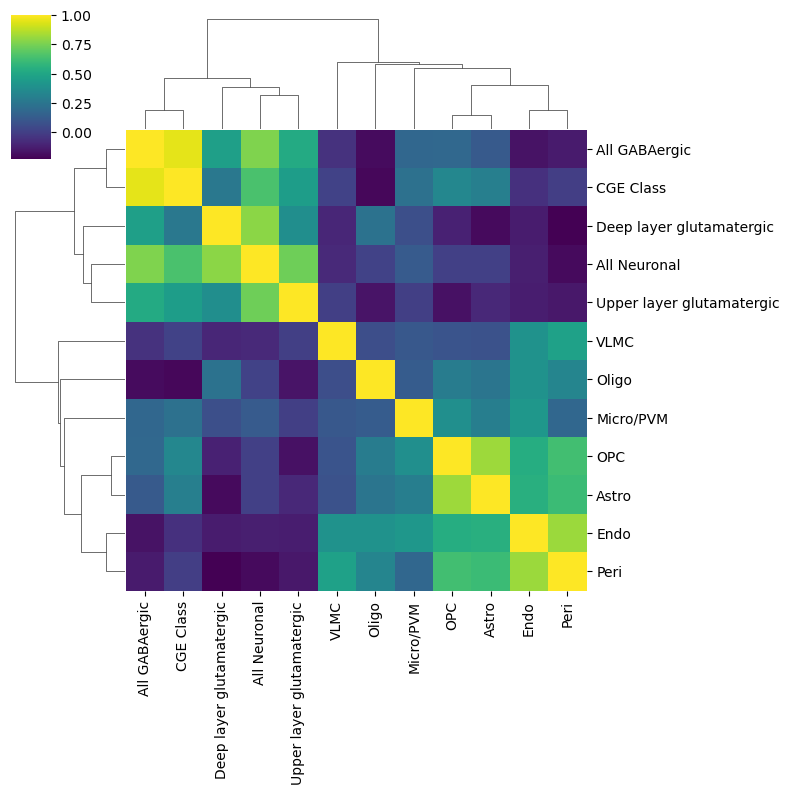

In [ ]:
abund_corr_mat = ctype_abundance_filt.corr()
sns.clustermap(abund_corr_mat, cmap='viridis', figsize=(8, 8))

In [ ]:
ctype_abundance_filt.to_csv("data/GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance_filtered.csv")